<a href="https://colab.research.google.com/github/sdg331/BDA/blob/main/09w_data_vis_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09주차 파이썬 데이터 시각화

## 0. 시각화 기본 준비

In [1]:
# 한글 처리 패키지 설치
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.6 MB/s eta 0:00:00


In [4]:
# pydataset 설치
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 49.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=85d042bad31ba15c46cdbb650b3d3fbc00dc9fa8d8c8f55aeff52bb58a34c24e
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [5]:
# pydataset 사용
from pydataset import data

initiated datasets repo at: /root/.pydataset/


In [6]:
# 한글 처리
import koreanize_matplotlib

# 그래프 선명도 설정
%config InlineBackend.figure_format = 'retina'

In [7]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pydataset 사용
from pydataset import data

# 그래프 크기 기본값
plt.rcParams['figure.figsize'] = (5, 3)

In [8]:
# 현재 figure 크기 확인
plt.rcParams['figure.figsize']

[5.0, 3.0]

In [9]:
# pydataset 설치 확인
!pip show pydataset

Name: pydataset
Version: 0.2.0
Summary: Provides instant access to many popular datasets right from Python (in dataframe structure).
Home-page: https://github.com/iamaziz/PyDataset
Author: Aziz Alto
Author-email: iamaziz.alto@gmail.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: pandas
Required-by: 


In [10]:
# pydataset 설치
!pip install pydataset

## 9.1 산점도와 막대 그래프

### 산점도 개요와 함수 scatter()

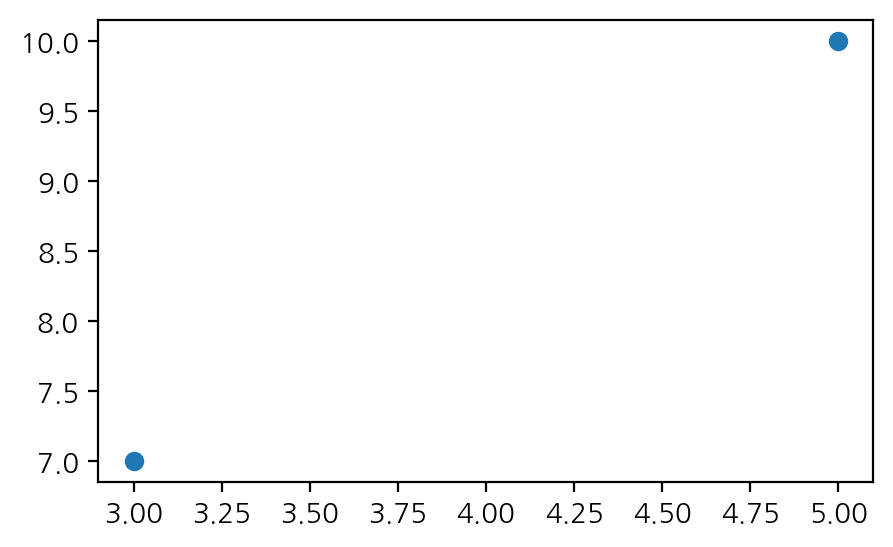

In [11]:
# x값 2개, y값 2개로 산점도 그리기
import matplotlib.pyplot as plt

plt.scatter([3, 5], [7, 10])
plt.show()

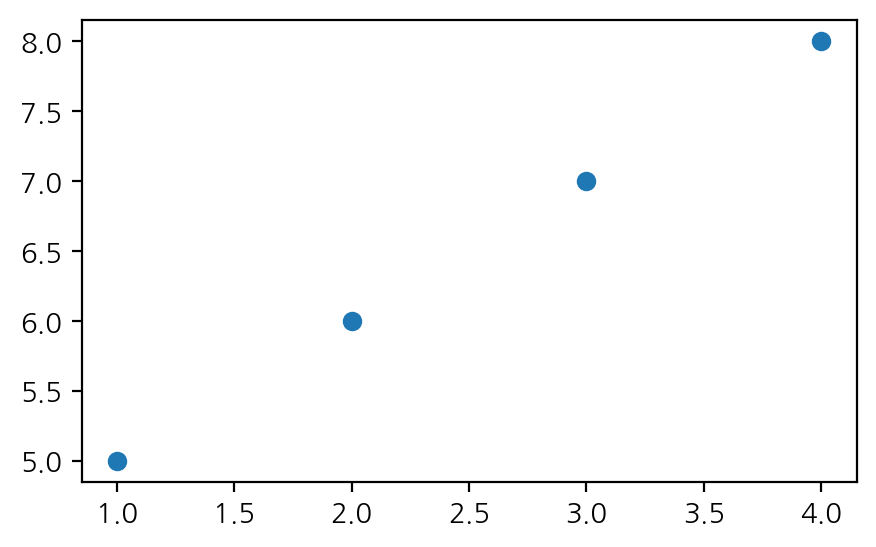

In [12]:
# range() 결과로 산점도 그리기
plt.scatter(range(1, 5), range(5, 9))
plt.show()

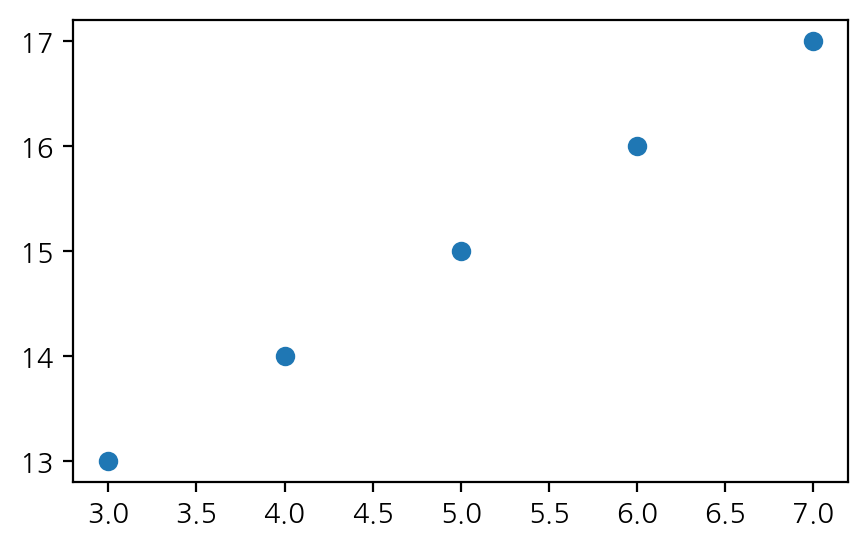

In [13]:
# range() 시작과 끝을 바꿔 산점도 그리기
plt.scatter(range(3, 8), range(13, 18))
plt.show()

### 내장 데이터 ToothGrowth

In [14]:
# ToothGrowth 데이터 불러오기
from pydataset import data

tg = data('ToothGrowth')
tg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.9+ KB


In [15]:
# 앞부분 확인
tg.head()

,len,supp,dose
1,4.2,VC,0.5
2,11.5,VC,0.5
3,7.3,VC,0.5
4,5.8,VC,0.5
5,6.4,VC,0.5


In [16]:
# 뒷부분 확인
tg.tail()

,len,supp,dose
56,30.9,OJ,2.0
57,26.4,OJ,2.0
58,27.3,OJ,2.0
59,29.4,OJ,2.0
60,23.0,OJ,2.0


In [17]:
# 보충제 종류 빈도 확인
tg.supp.value_counts()

,count
supp,
VC,30
OJ,30


In [18]:
# 용량 수준 빈도 확인
tg.dose.value_counts()

,count
dose,
0.5,20
1.0,20
2.0,20


In [19]:
# 데이터 정보 확인
tg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.9+ KB


In [20]:
# 기초 통계 확인
tg.describe()

,len,dose
count,60.000000,60.000000
mean,18.813333,1.166667
std,7.649315,0.628872
min,4.200000,0.500000
25%,13.075000,0.500000
50%,19.250000,1.000000
75%,25.275000,2.000000
max,33.900000,2.000000


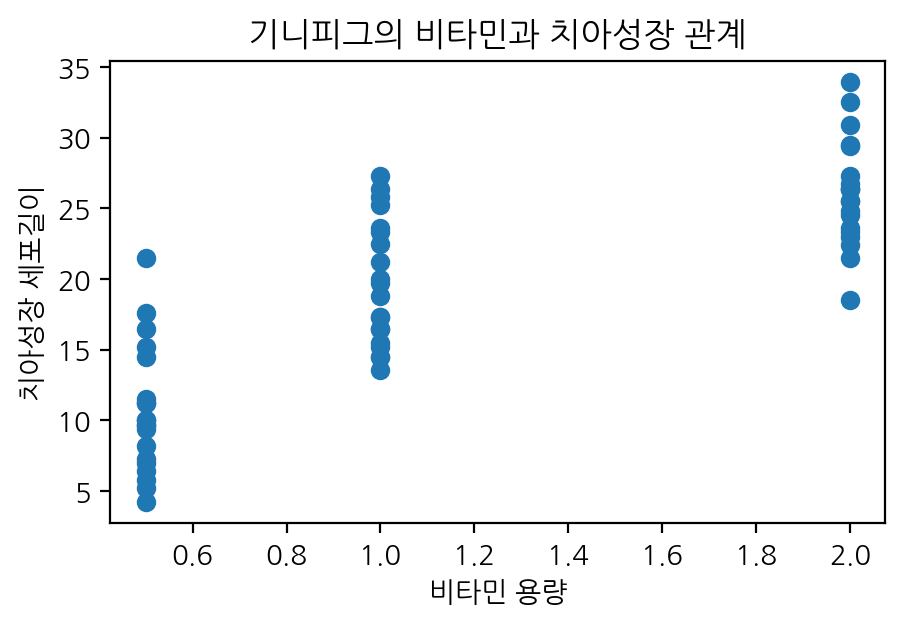

In [21]:
# 비타민 용량과 치아세포 길이 산점도
plt.scatter(tg.dose, tg.len)
plt.title('기니피그의 비타민과 치아성장 관계')
plt.xlabel('비타민 용량')
plt.ylabel('치아성장 세포길이')
plt.show()

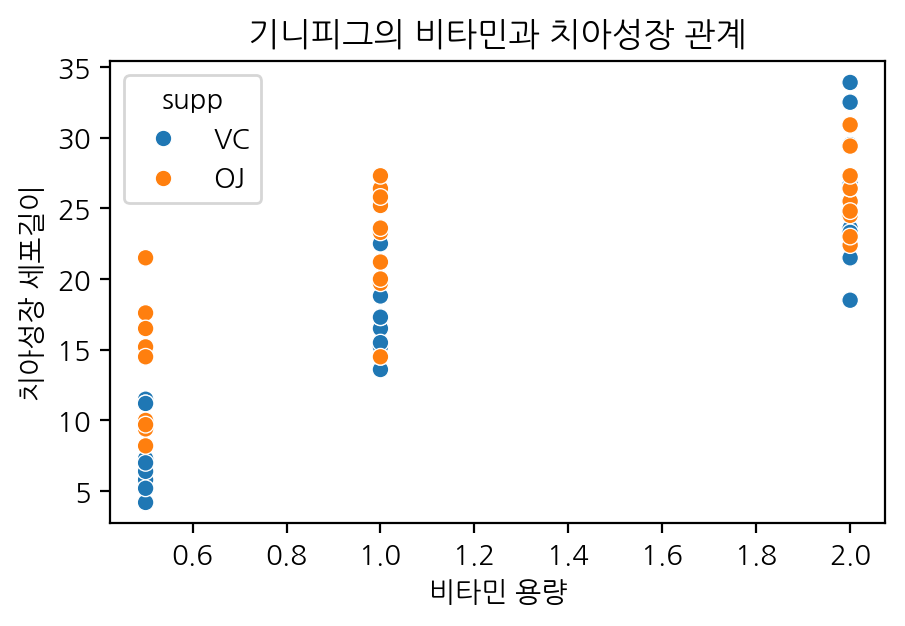

In [22]:
# 보충제 종류를 색상으로 구분한 산점도
sns.scatterplot(data=tg, x='dose', y='len', hue='supp')
plt.title('기니피그의 비타민과 치아성장 관계')
plt.xlabel('비타민 용량')
plt.ylabel('치아성장 세포길이')
plt.show()

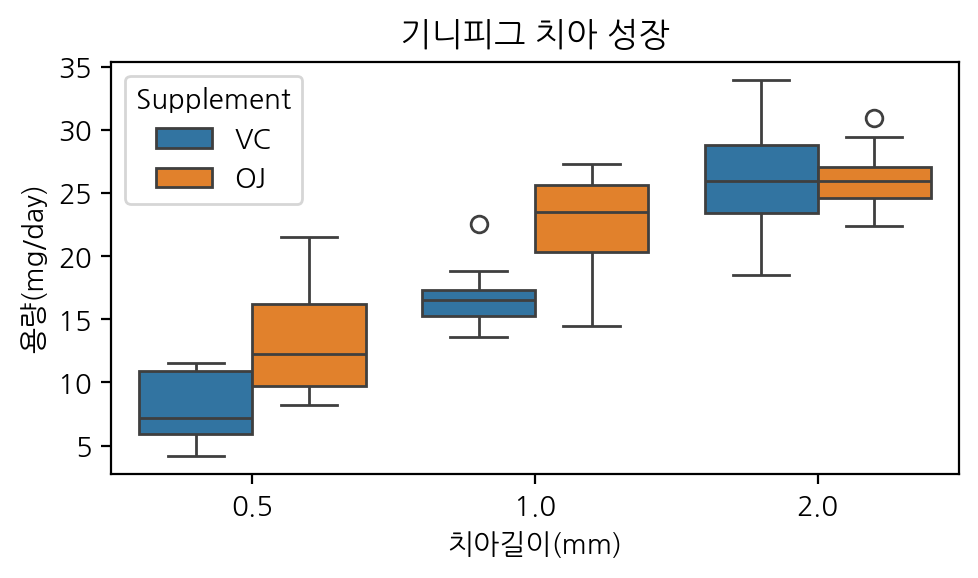

In [23]:
# 상자그림
sns.boxplot(data=tg, x='dose', y='len', hue='supp')
plt.title('기니피그 치아 성장')
plt.xlabel('치아길이(mm)')
plt.ylabel('용량(mg/day)')
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

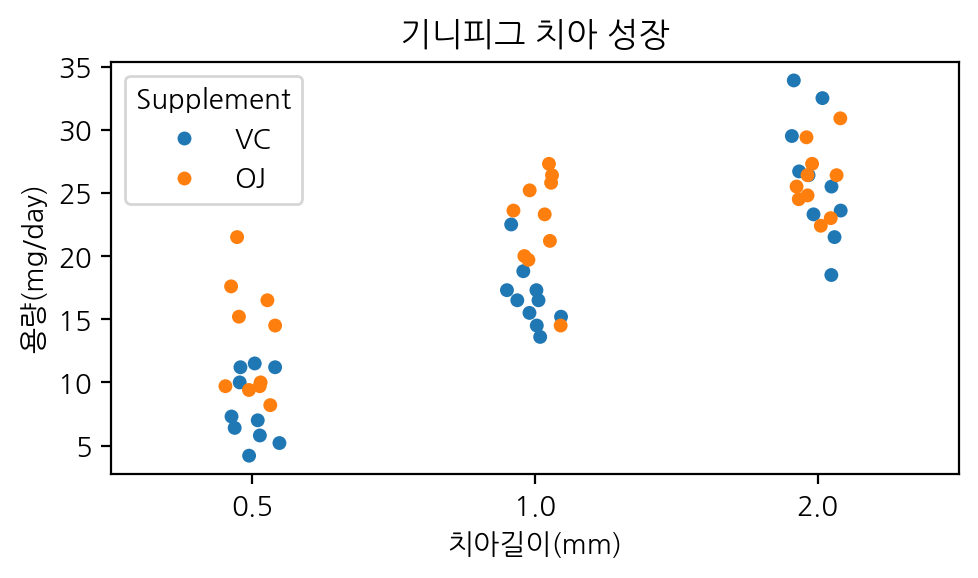

In [24]:
# stripplot
sns.stripplot(data=tg, x='dose', y='len', hue='supp')
plt.title('기니피그 치아 성장')
plt.xlabel('치아길이(mm)')
plt.ylabel('용량(mg/day)')
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

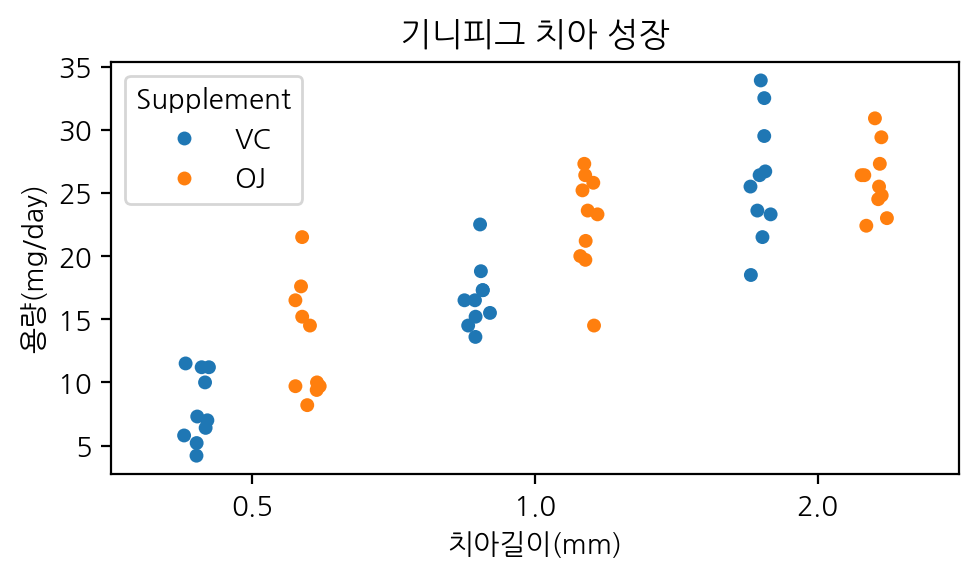

In [25]:
# dodge 적용 stripplot
sns.stripplot(data=tg, x='dose', y='len', hue='supp', dodge=True)
plt.title('기니피그 치아 성장')
plt.xlabel('치아길이(mm)')
plt.ylabel('용량(mg/day)')
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

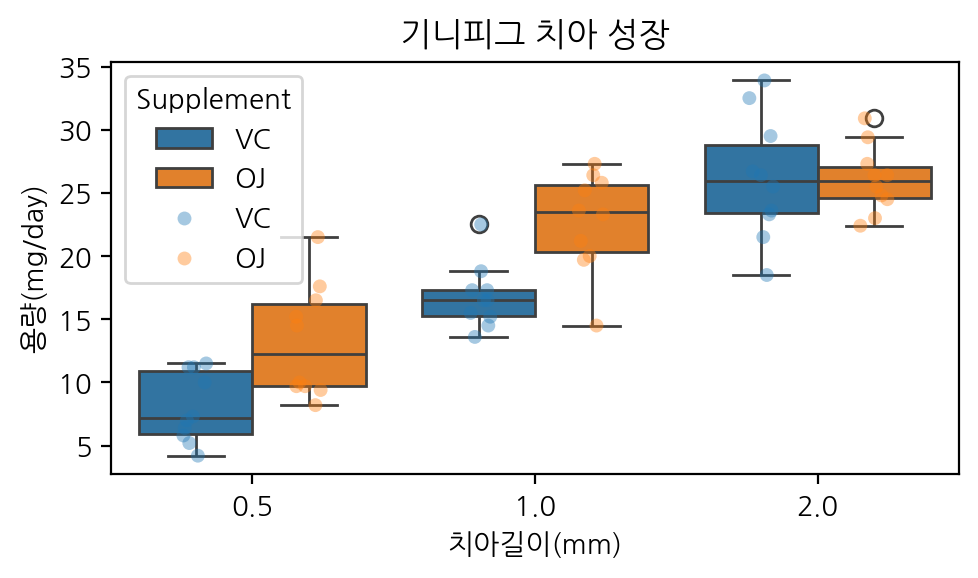

In [26]:
# boxplot과 stripplot 함께 그리기
sns.boxplot(data=tg, x='dose', y='len', hue='supp')
sns.stripplot(data=tg, x='dose', y='len', hue='supp', dodge=True, alpha=0.4)

plt.title('기니피그 치아 성장')
plt.xlabel('치아길이(mm)')
plt.ylabel('용량(mg/day)')
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

### 선 그리기 함수 plot()

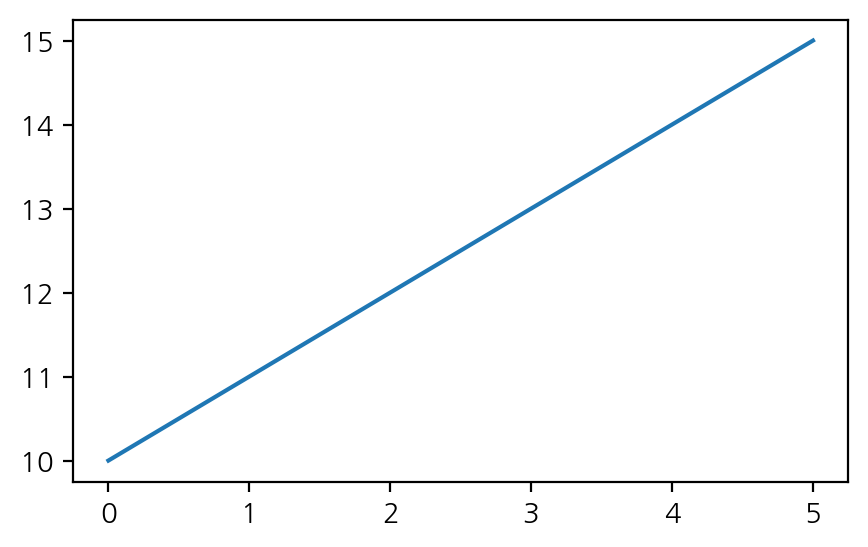

In [27]:
# 기본 선 그래프
plt.plot(range(10, 16))
plt.show()

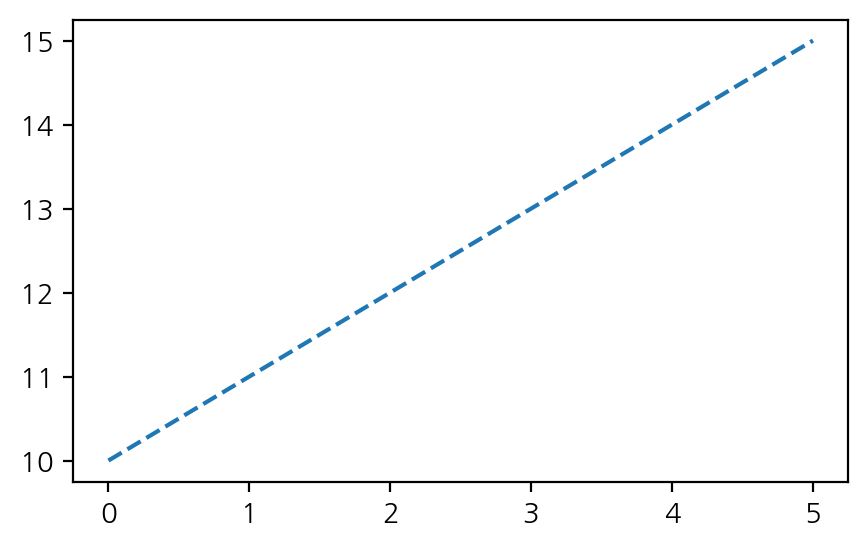

In [28]:
# 점선 그래프
plt.plot(range(10, 16), linestyle='--')
plt.show()

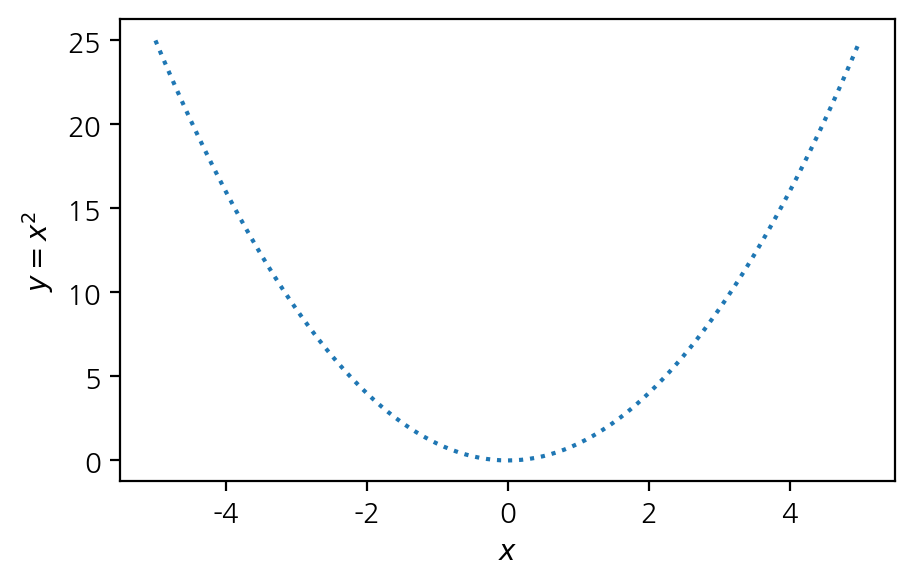

In [29]:
# x축 -5에서 5까지 y=x^2 그래프
import numpy as np

x = np.arange(-5, 5.1, 0.1)
plt.plot(x, x**2, ls=':')
plt.xlabel('$x$')
plt.ylabel('$y=x^2$')
plt.show()

### 내장 데이터 AirPassengers

In [30]:
# AirPassengers 데이터 불러오기
airpsngr = data('AirPassengers')
airpsngr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1 to 144
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           144 non-null    float64
 1   AirPassengers  144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


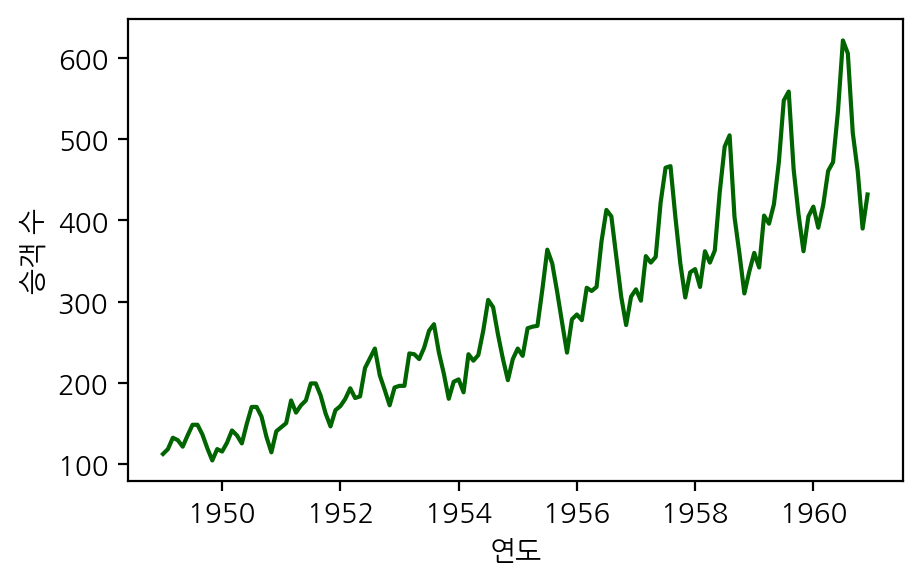

In [31]:
# 월별 국제선 승객 수 그래프
plt.plot(airpsngr.time, airpsngr.AirPassengers, color='darkgreen')
plt.xlabel('연도')
plt.ylabel('승객 수')
plt.show()

### linestyle과 marker

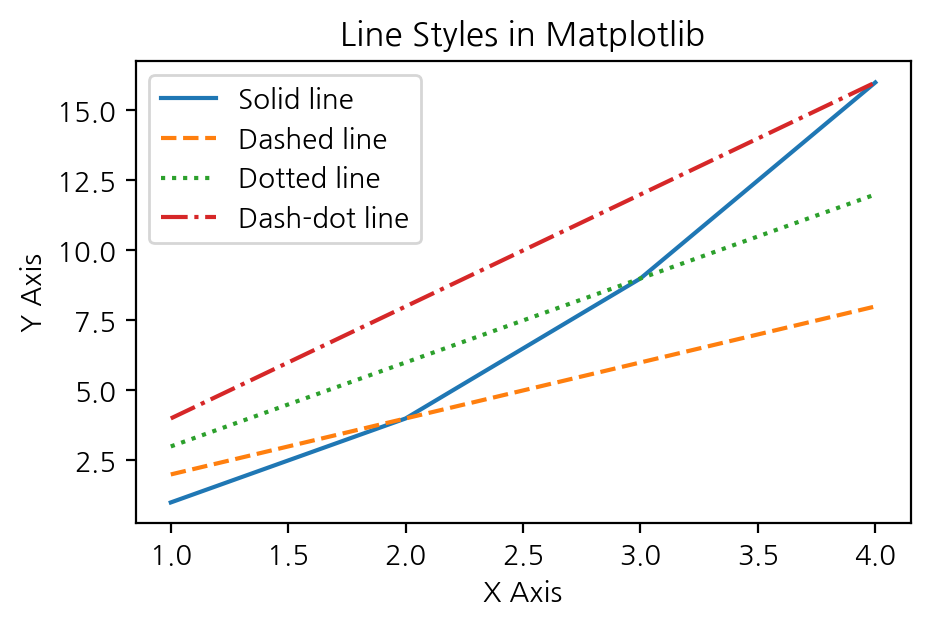

In [32]:
# 다양한 선 종류
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 4, 6, 8]
y3 = [3, 6, 9, 12]
y4 = [4, 8, 12, 16]

plt.plot(x, y1, linestyle='-',  label='Solid line')
plt.plot(x, y2, linestyle='--', label='Dashed line')
plt.plot(x, y3, linestyle=':',  label='Dotted line')
plt.plot(x, y4, linestyle='-.', label='Dash-dot line')

plt.title('Line Styles in Matplotlib')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.show()

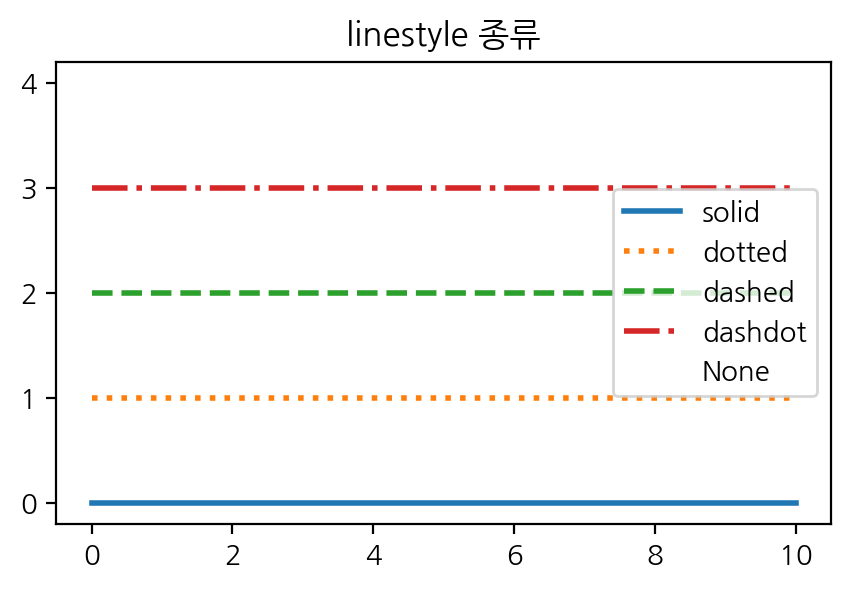

In [33]:
# 다양한 선 스타일을 수평선으로 비교
x = np.linspace(0, 10, 100)

styles = ['solid', 'dotted', 'dashed', 'dashdot', 'None']

for i, style in enumerate(styles):
    plt.plot(x, [i] * len(x), linestyle=style, linewidth=2, label=style)

plt.legend()
plt.title('linestyle 종류')
plt.show()

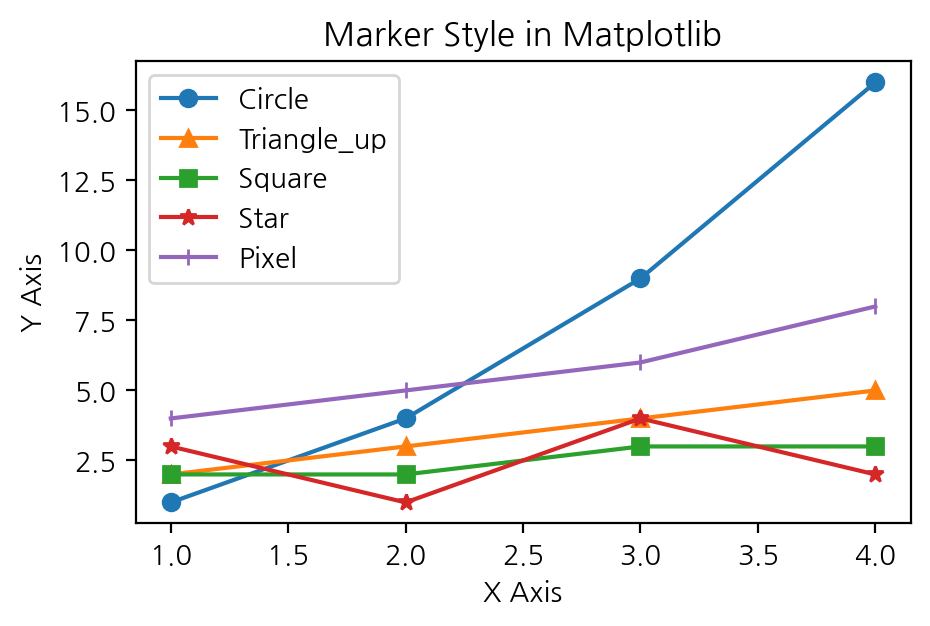

In [34]:
# 5개 마커 사용
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 3, 4, 5]
y3 = [2, 2, 3, 3]
y4 = [3, 1, 4, 2]
y5 = [4, 5, 6, 8]

plt.plot(x, y1, marker='o', label='Circle')
plt.plot(x, y2, marker='^', label='Triangle_up')
plt.plot(x, y3, marker='s', label='Square')
plt.plot(x, y4, marker='*', label='Star')
plt.plot(x, y5, marker='|', label='Pixel')

plt.title('Marker Style in Matplotlib')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.show()

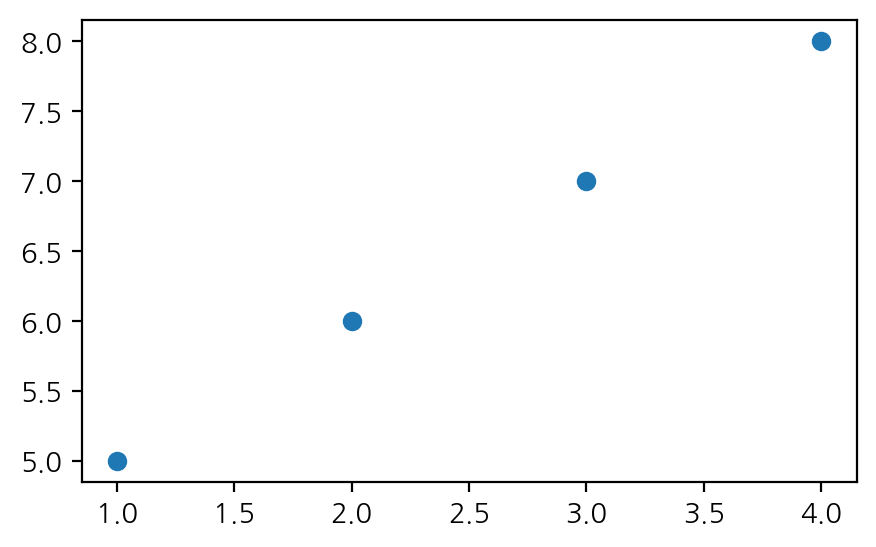

In [35]:
# 선 없이 마커만 표시
plt.plot(range(1, 5), range(5, 9), ls=' ', marker='o')
plt.show()

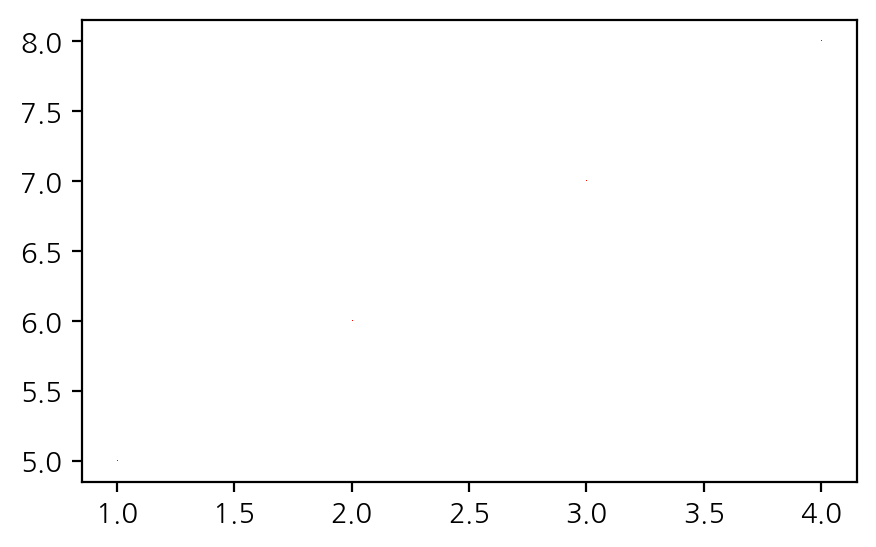

In [36]:
# 선 없이 픽셀 마커 표시
plt.plot([1, 2, 3, 4], [5, 6, 7, 8], ls='', marker=',', color='red')
plt.show()

### 비타민 종류와 용량에 따른 치아 성장 차이

In [37]:
# VC와 OJ 데이터 분리
vc = tg[tg.supp == "VC"][['len', 'dose']]
oj = tg[tg.supp == "OJ"][['len', 'dose']]

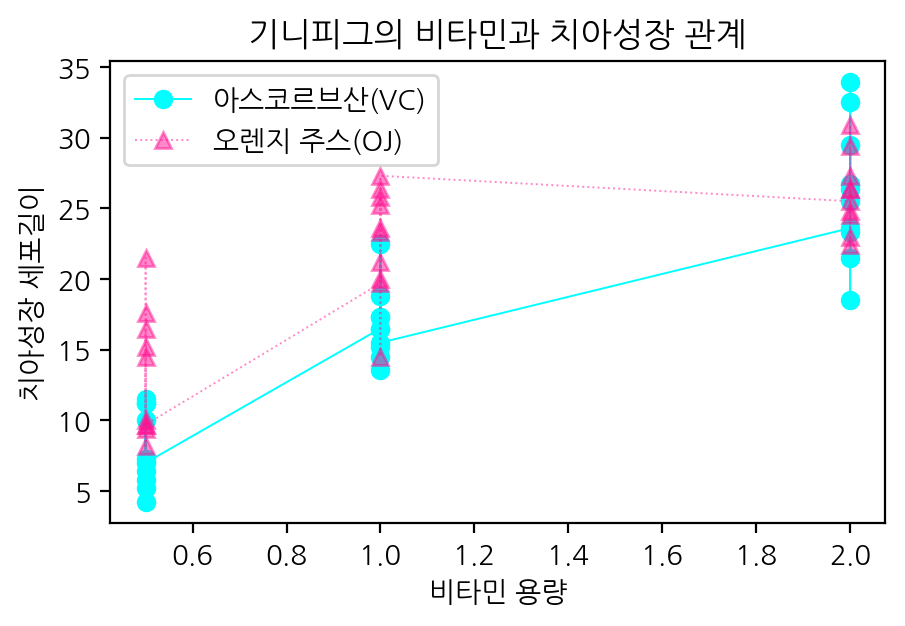

In [38]:
# VC와 OJ 비교 그래프
plt.plot(vc.dose, vc.len, color='cyan', marker='o',
         label='아스코르브산(VC)', lw=.7)
plt.plot(oj.dose, oj.len, color='deeppink', marker='^', ls=':',
         label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend()
plt.show()

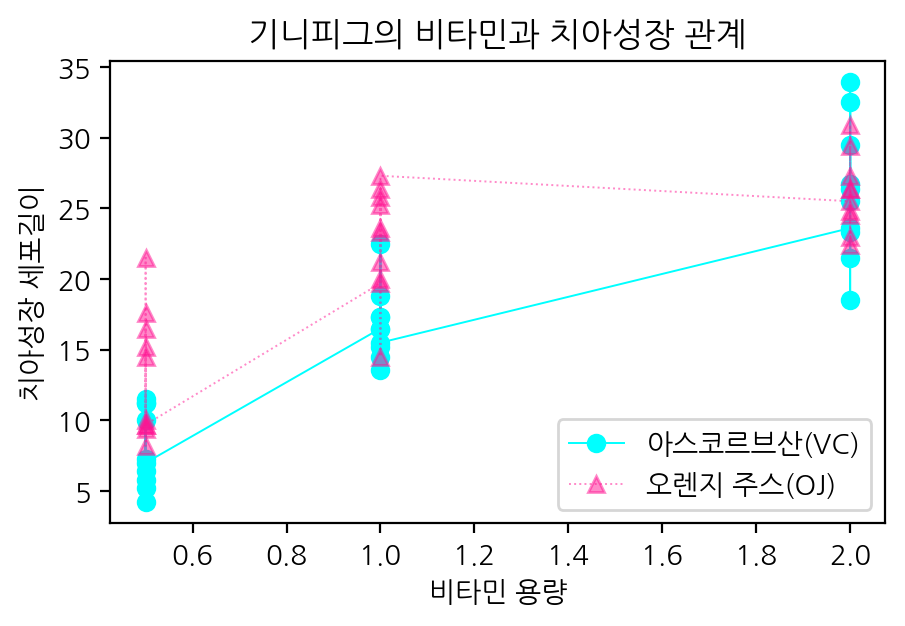

In [39]:
# 범례 위치 지정
plt.plot(vc.dose, vc.len, color='cyan', marker='o',
         label='아스코르브산(VC)', lw=.7)
plt.plot(oj.dose, oj.len, color='deeppink', marker='^', ls=':',
         label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend(loc='lower right')
plt.show()

### 막대 그래프 함수 bar(), barh()

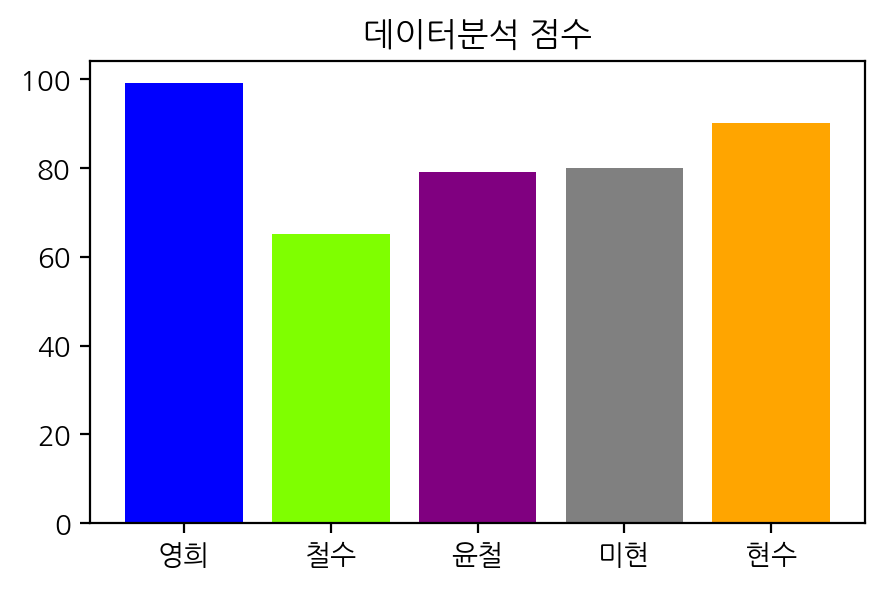

In [40]:
# 세로 막대 그래프
point = [99, 65, 79, 80, 90]
name = ["영희", "철수", "윤철", "미현", "현수"]

plt.bar(name, point, color=["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수')
plt.show()

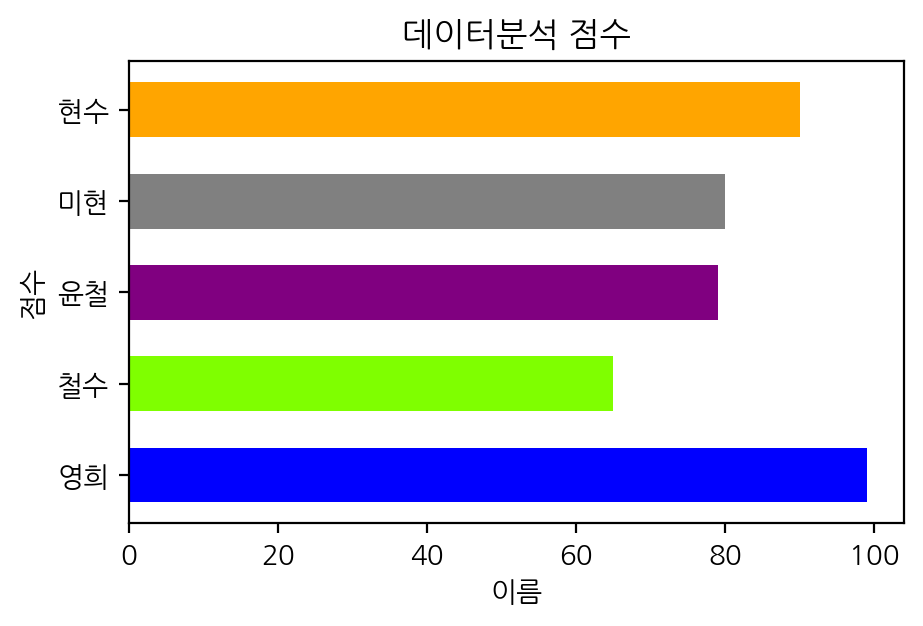

In [41]:
# 가로 막대 그래프
plt.barh(name, point, height=.6,
         color=["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수')
plt.xlabel('이름')
plt.ylabel('점수')
plt.show()

### 내장 데이터 LifeCycleSavings

In [42]:
# LifeCycleSavings 데이터 불러오기
lcs = data('LifeCycleSavings')
lcs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Australia to Malaysia
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      50 non-null     float64
 1   pop15   50 non-null     float64
 2   pop75   50 non-null     float64
 3   dpi     50 non-null     float64
 4   ddpi    50 non-null     float64
dtypes: float64(5)
memory usage: 2.3+ KB


In [43]:
# 기초 통계 확인
lcs.describe()

,sr,pop15,pop75,dpi,ddpi
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,9.671000,35.089600,2.293000,1106.758400,3.757600
std,4.480407,9.151727,1.290771,990.868889,2.869871
min,0.600000,21.440000,0.560000,88.940000,0.220000
25%,6.970000,26.215000,1.125000,288.207500,2.002500
50%,10.510000,32.575000,2.175000,695.665000,3.000000
75%,12.617500,44.065000,3.325000,1795.622500,4.477500
max,21.100000,47.640000,4.700000,4001.890000,16.710000


In [44]:
# 앞부분 5개 국가의 pop15 확인
df_pop15 = lcs[:5][['pop15']]
df_pop15

,pop15
Australia,29.35
Austria,23.32
Belgium,23.80
Bolivia,41.89
Brazil,42.19


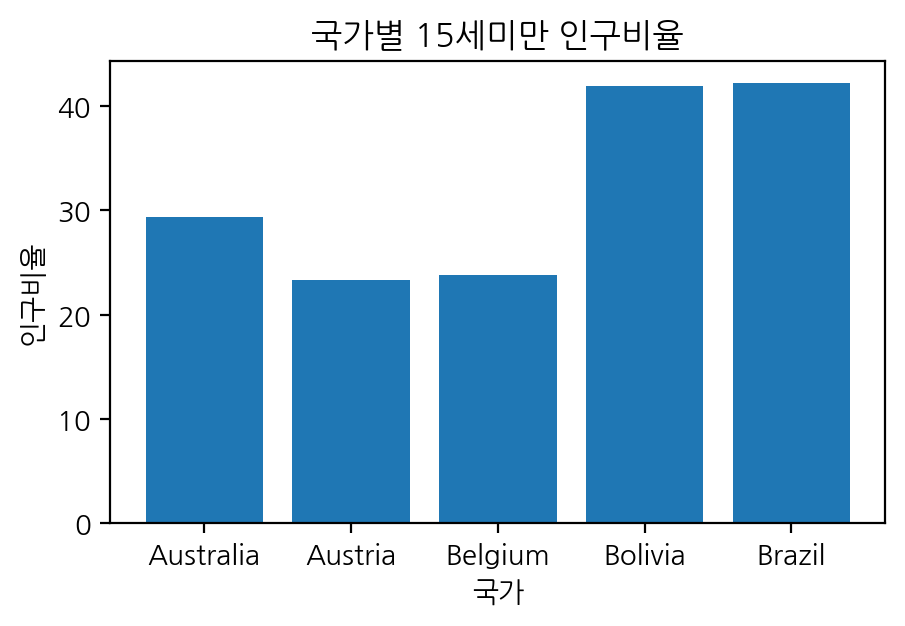

In [45]:
# 국가별 15세 미만 인구비율
plt.bar(df_pop15.index, df_pop15.pop15)
plt.title("국가별 15세미만 인구비율")
plt.xlabel("국가")
plt.ylabel("인구비율")
plt.show()

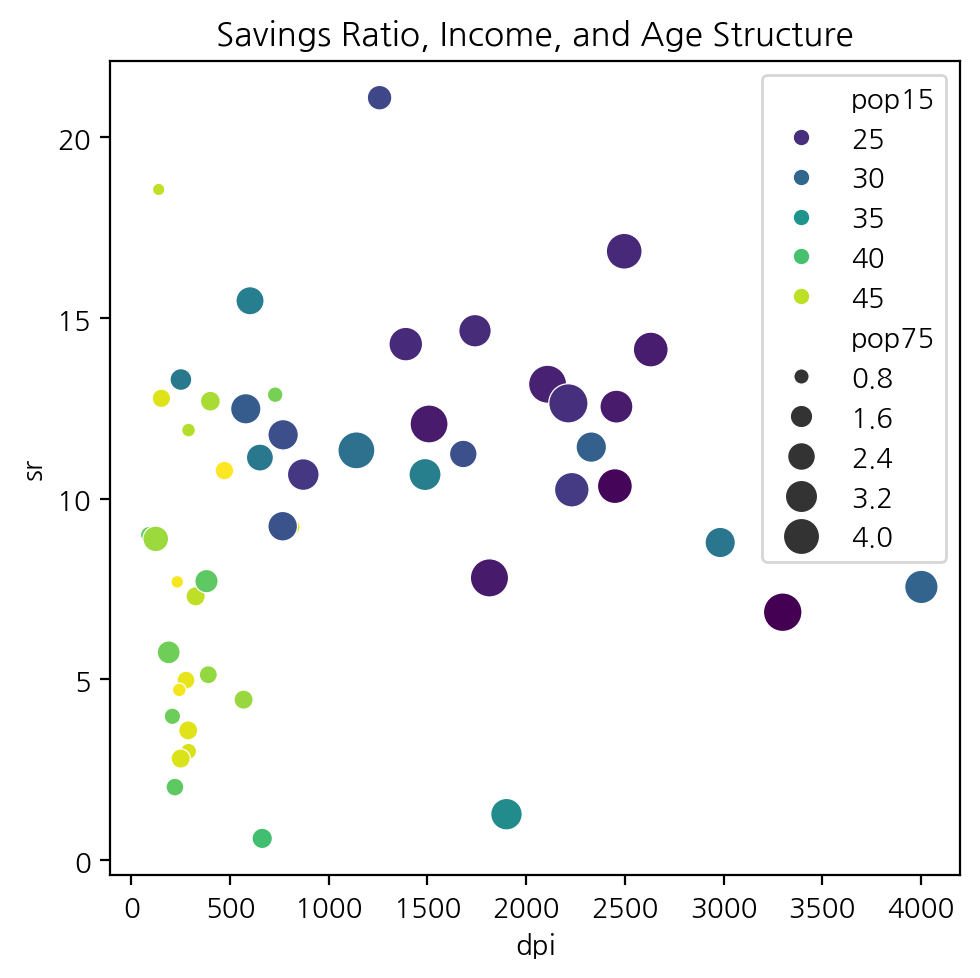

In [46]:
# 저축률, 소득, 연령 구조 비교 산점도
plt.figure(figsize=(5, 5))

sns.scatterplot(data=lcs, x='dpi', y='sr', hue='pop15',
                palette='viridis', size='pop75', sizes=(20, 200))

plt.title('Savings Ratio, Income, and Age Structure')
plt.xlabel('dpi')
plt.ylabel('sr')
plt.tight_layout()
plt.show()

In [47]:
# 인덱스 확인
lcs.index

Index(['Australia', 'Austria', 'Belgium', 'Bolivia', 'Brazil', 'Canada',
       'Chile', 'China', 'Colombia', 'Costa Rica', 'Denmark', 'Ecuador',
       'Finland', 'France', 'Germany', 'Greece', 'Guatamala', 'Honduras',
       'Iceland', 'India', 'Ireland', 'Italy', 'Japan', 'Korea', 'Luxembourg',
       'Malta', 'Norway', 'Netherlands', 'New Zealand', 'Nicaragua', 'Panama',
       'Paraguay', 'Peru', 'Philippines', 'Portugal', 'South Africa',
       'South Rhodesia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'Tunisia',
       'United Kingdom', 'United States', 'Venezuela', 'Zambia', 'Jamaica',
       'Uruguay', 'Libya', 'Malaysia'],
      dtype='object')

In [48]:
# Korea가 포함된 행 검색
lcs[lcs.index.str.contains('Korea')]

,sr,pop15,pop75,dpi,ddpi
Korea,3.98,41.74,0.91,207.68,5.81


In [49]:
# isin 사용
lcs[lcs.index.isin(['Korea'])]

,sr,pop15,pop75,dpi,ddpi
Korea,3.98,41.74,0.91,207.68,5.81


In [50]:
# 여러 국가 선택
lcs[lcs.index.isin(['Korea', 'Japan', 'United States'])]

,sr,pop15,pop75,dpi,ddpi
Japan,21.10,27.01,1.91,1257.28,8.21
Korea,3.98,41.74,0.91,207.68,5.81
United States,7.56,29.81,3.43,4001.89,2.45


In [51]:
# dpi 내림차순 정렬
lcs.dpi.sort_values(ascending=False)

,dpi
United States,4001.89
Sweden,3299.49
Canada,2982.88
Switzerland,2630.96
Denmark,2496.53
Germany,2457.12
Luxembourg,2449.39
Australia,2329.68
Norway,2231.03
France,2213.82


### 데이터셋 mtcars

In [52]:
# mtcars 데이터 불러오기
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [53]:
# 앞부분 확인
mtc.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [54]:
# cyl 빈도수
mtc_cyl = mtc.cyl.value_counts()
mtc_cyl

,count
cyl,
8,14
4,11
6,7


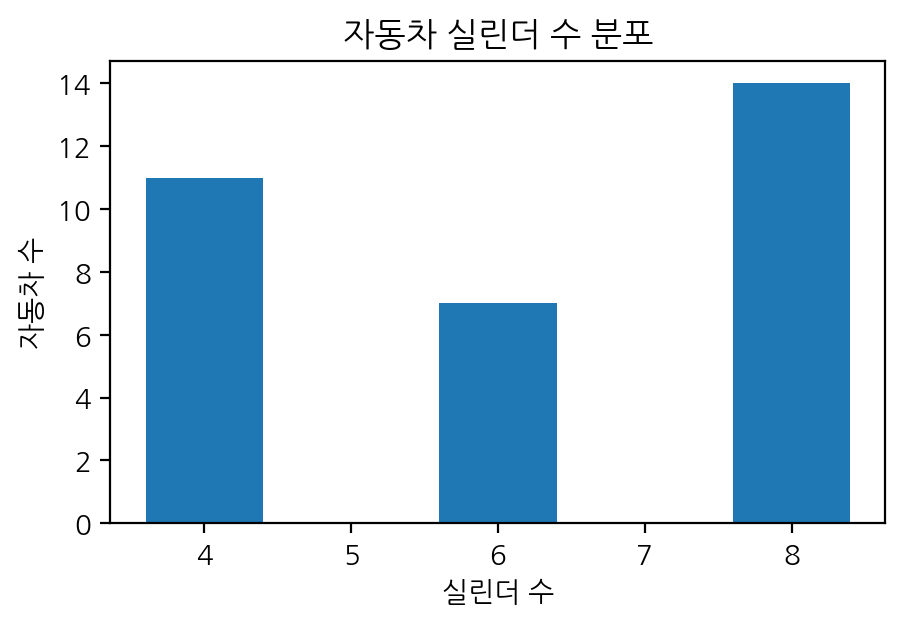

In [55]:
# cyl 빈도수 막대그래프
plt.bar(mtc_cyl.index, mtc_cyl)
plt.title("자동차 실린더 수 분포")
plt.xlabel("실린더 수")
plt.ylabel("자동차 수")
plt.show()

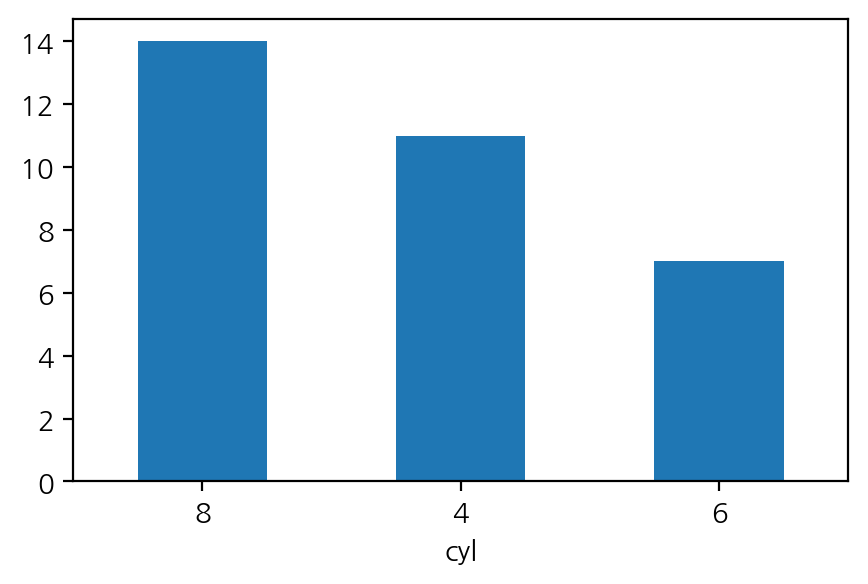

In [56]:
# Series의 plot.bar() 사용
mtc.cyl.value_counts().plot.bar()
plt.xticks(rotation=360)
plt.show()

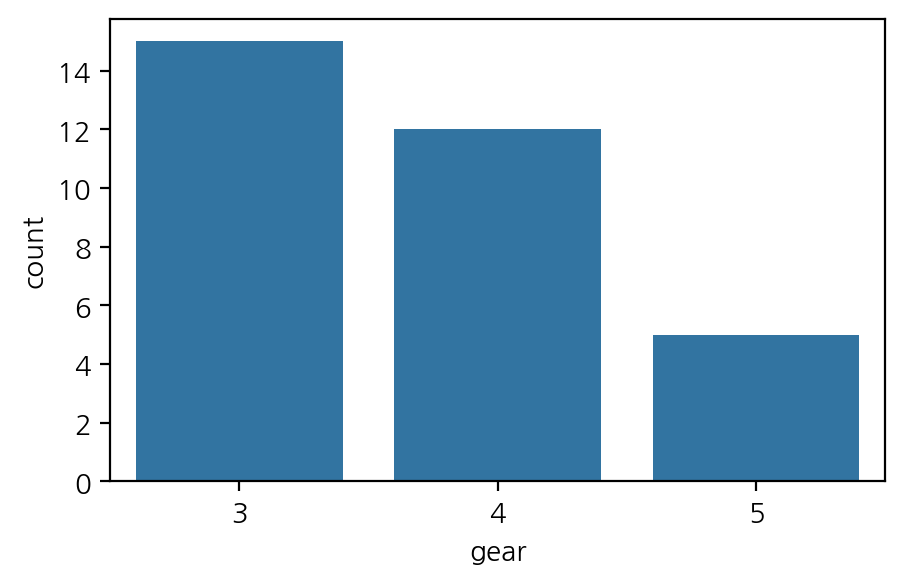

In [57]:
# seaborn countplot
ax = sns.countplot(data=mtc, x='gear')
plt.show()

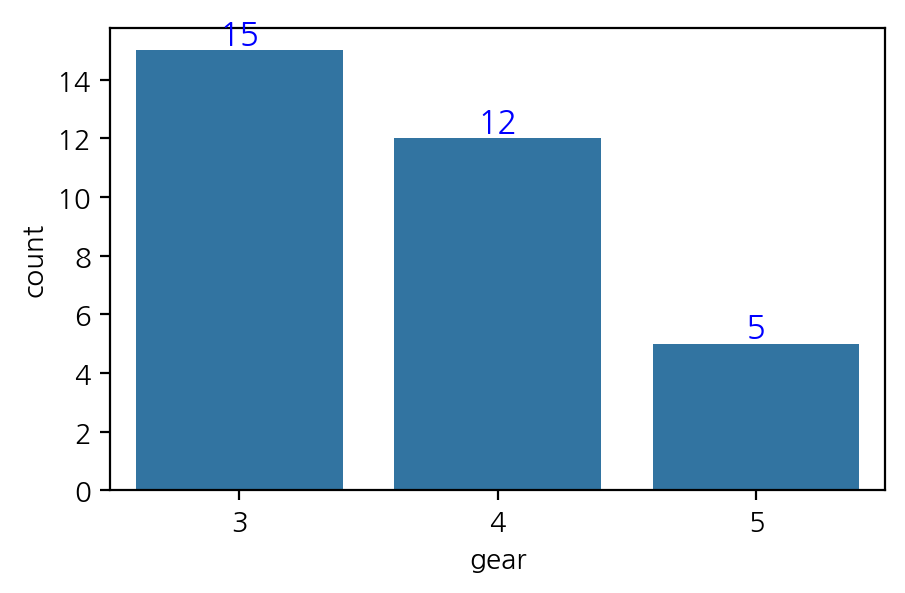

In [58]:
# countplot 막대 위에 빈도수 표시
ax = sns.countplot(data=mtc, x='gear',
                   order=mtc.gear.value_counts().index)

for p in ax.patches:
    height = p.get_height()
    ax.text(x=(p.get_x() + p.get_width() / 2.),
            y=(height + .2),
            s=int(height),
            ha='center',
            size=12,
            color='blue')

plt.show()

## 9.2 상자그림과 히스토그램

### 사분위수와 상자그림

In [59]:
# mpg 사분위수
mtc.mpg.quantile([0., .25, .50, .75, 1])

,mpg
0.00,10.400
0.25,15.425
0.50,19.200
0.75,22.800
1.00,33.900


In [60]:
# mpg describe 일부 확인
mtc.mpg.describe()[:3]

,mpg
count,32.000000
mean,20.090625
std,6.026948


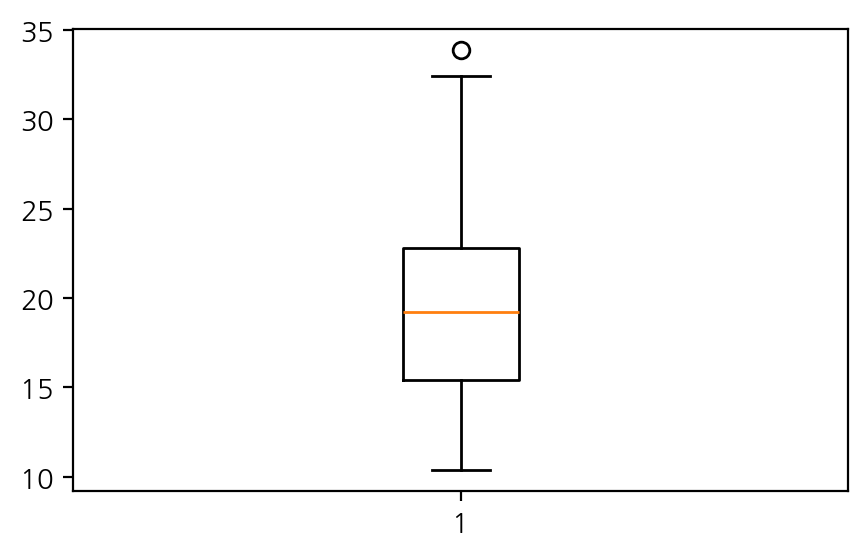

In [61]:
# boxplot 예시
plt.boxplot(mtc.mpg)
plt.show()

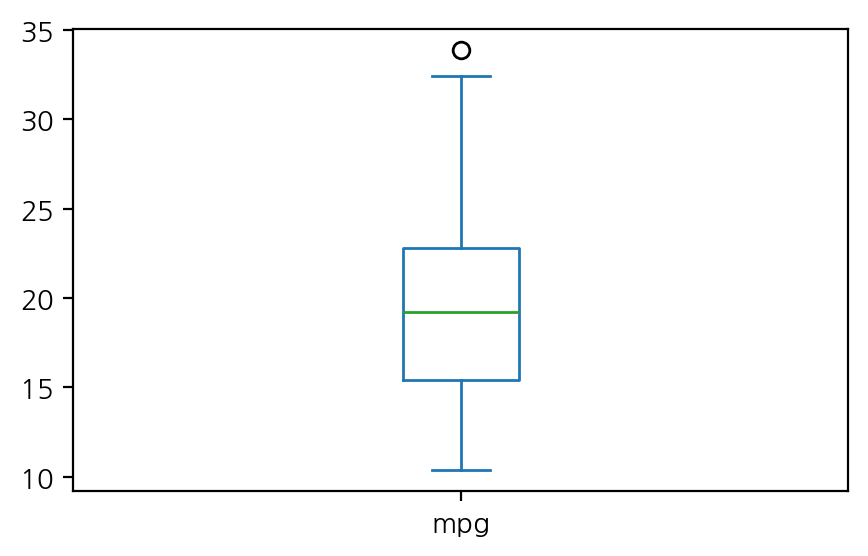

In [62]:
# Series plot.box()
mtc.mpg.plot.box()
plt.show()

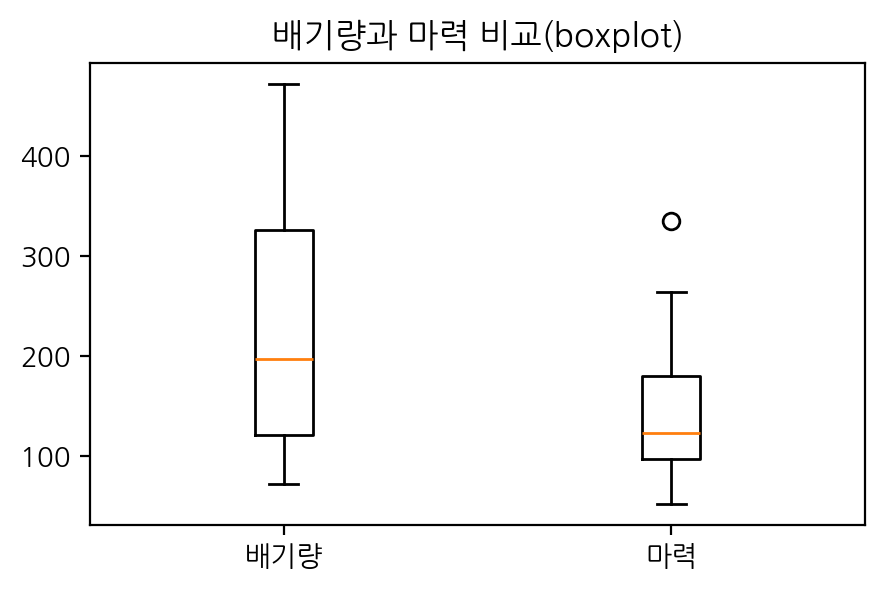

In [63]:
# disp와 hp 상자그림
plt.boxplot([mtc.disp, mtc.hp])
plt.title("배기량과 마력 비교(boxplot)")
plt.xticks(ticks=np.arange(1, 3), labels=["배기량", "마력"])
plt.show()

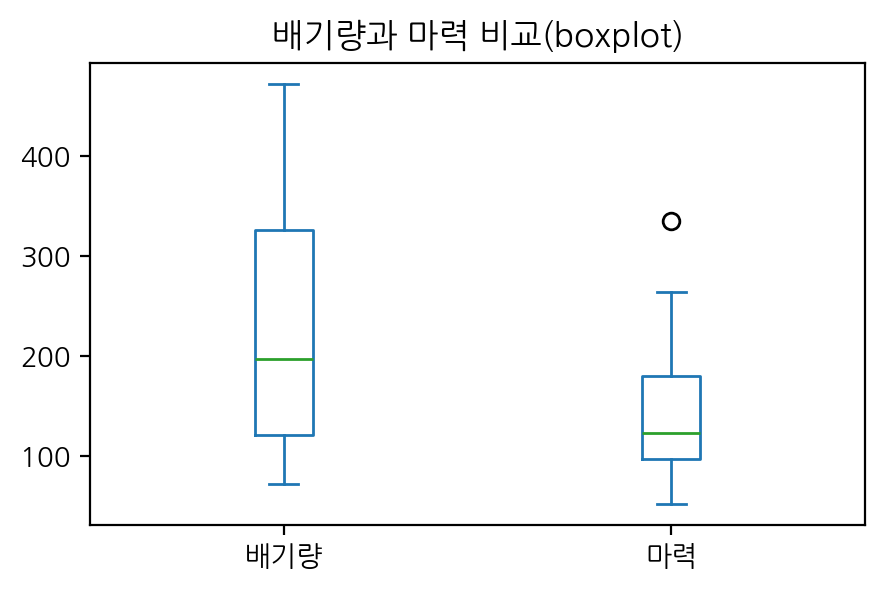

In [64]:
# DataFrame plot으로 상자그림
mtc[['disp', 'hp']].plot(title="배기량과 마력 비교(boxplot)", kind='box')
plt.xticks(ticks=np.arange(1, 3), labels=["배기량", "마력"])
plt.show()

### 함수 hist()를 활용한 히스토그램

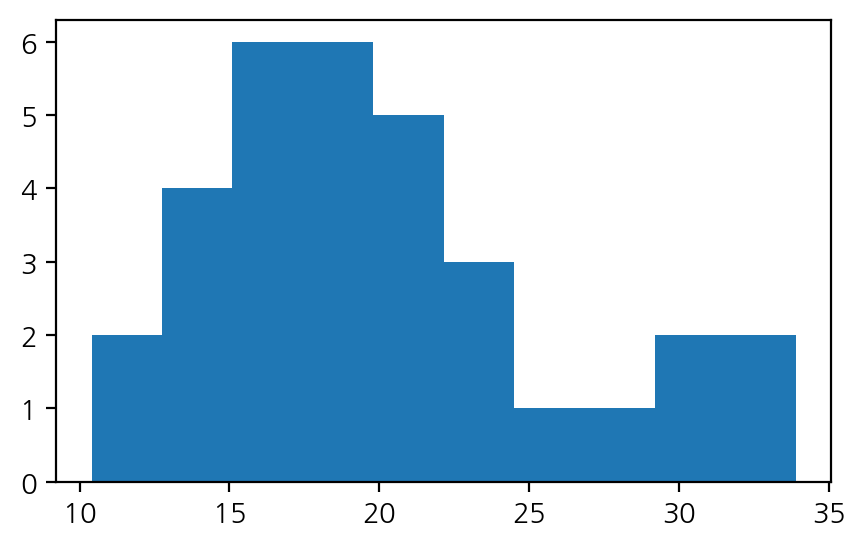

In [65]:
# mpg 히스토그램
plt.hist(mtc.mpg)
plt.show()

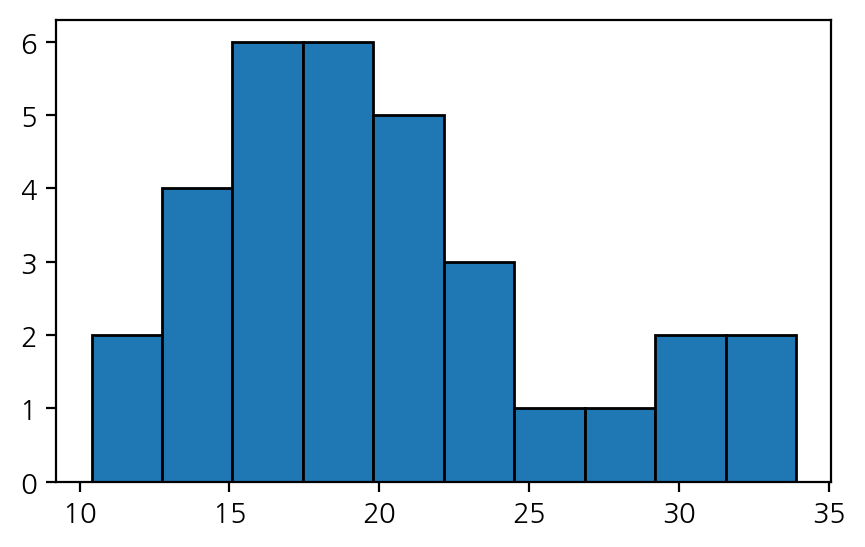

In [66]:
# edgecolor 지정
plt.hist(mtc.mpg, edgecolor='black')
plt.show()

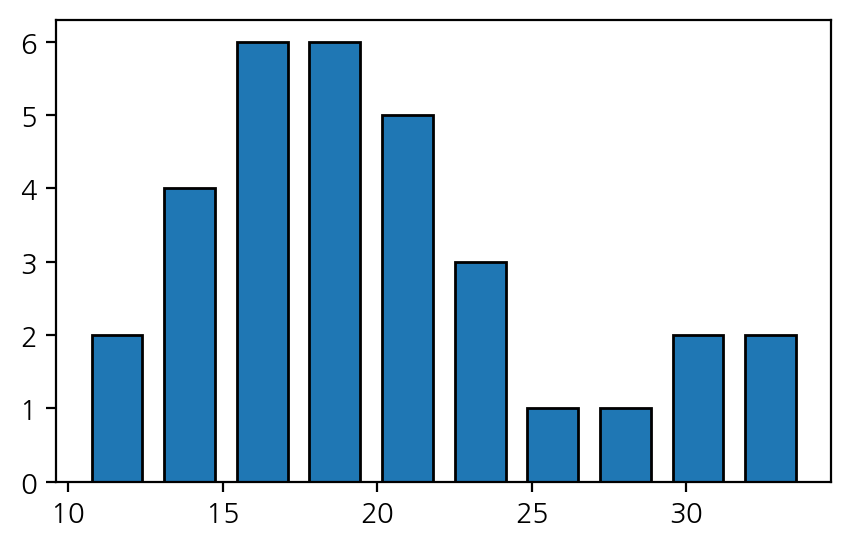

In [67]:
# rwidth 지정
plt.hist(mtc.mpg, edgecolor='black', rwidth=.7)
plt.show()

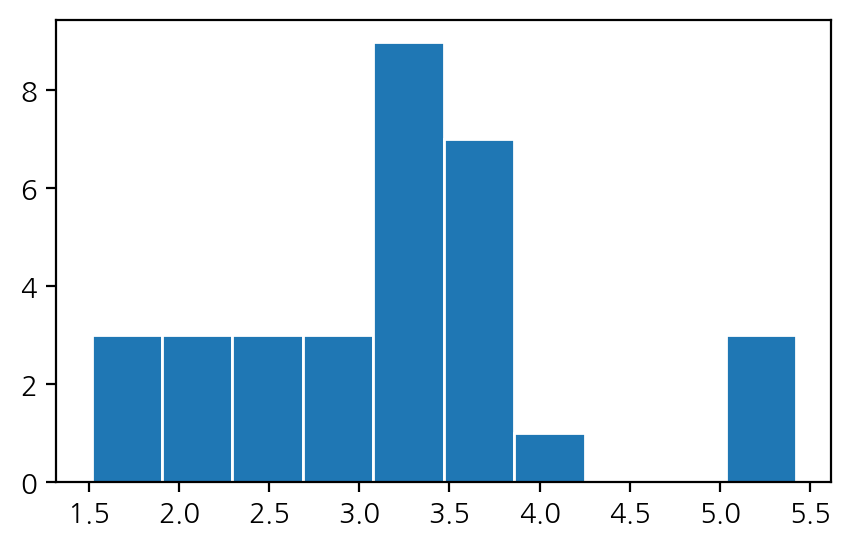

In [68]:
# wt 히스토그램
plt.hist(mtc.wt, edgecolor='white')
plt.show()

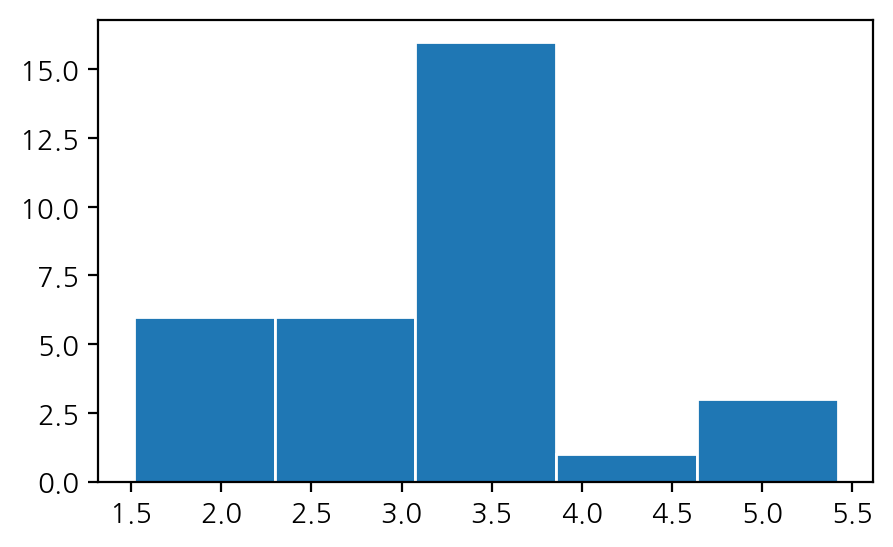

In [69]:
# wt 히스토그램, bins=5
plt.hist(mtc.wt, edgecolor='white', bins=5)
plt.show()

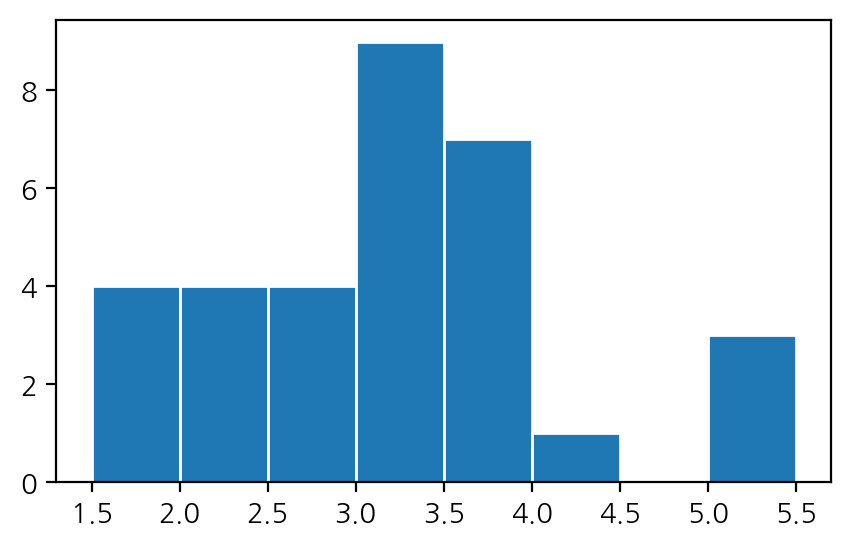

In [70]:
# bins를 arange로 직접 지정
plt.hist(mtc.wt, bins=np.arange(1.5, 5.6, 0.5), edgecolor='white')
plt.show()

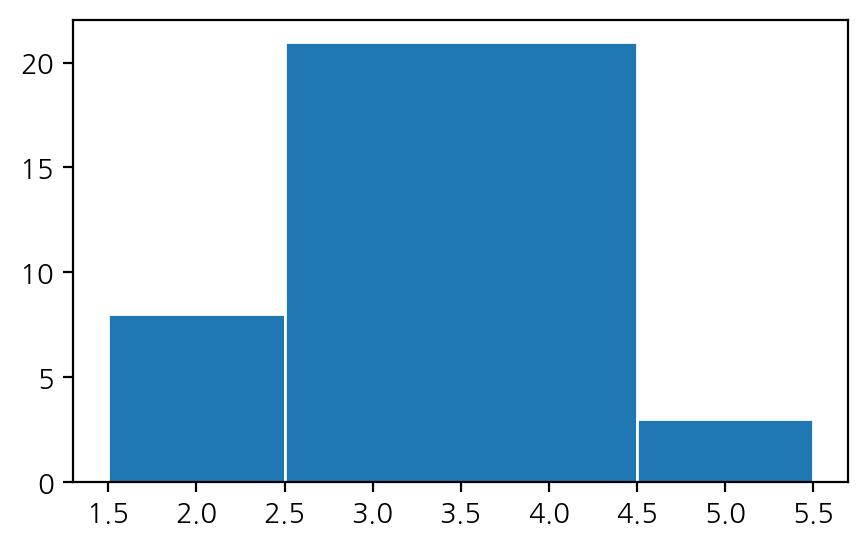

In [71]:
# bins를 리스트로 직접 지정
plt.hist(mtc.wt, bins=[1.5, 2.5, 4.5, 5.5], edgecolor='white')
plt.show()

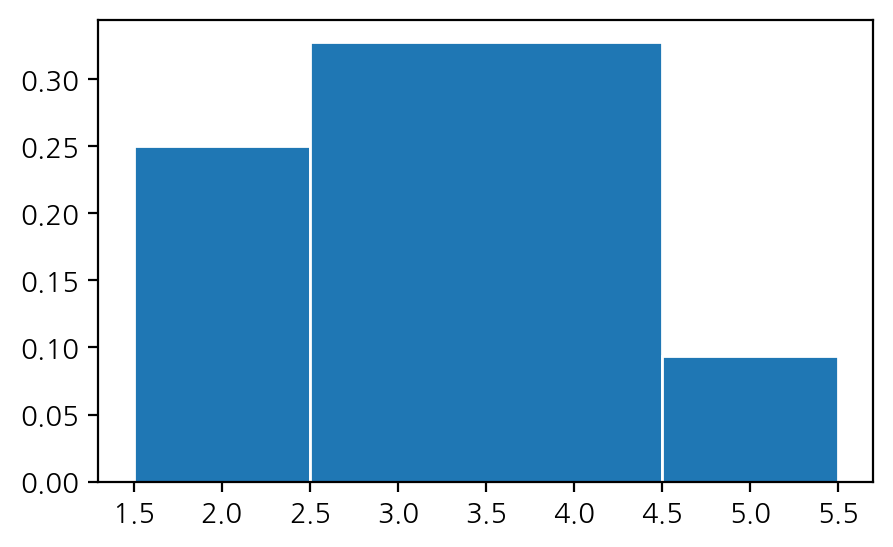

In [72]:
# density=True
plt.hist(mtc.wt, bins=[1.5, 2.5, 4.5, 5.5], density=True, edgecolor='white')
plt.show()

### 유명한 붓꽃 데이터 iris

In [73]:
# iris 데이터 불러오기
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [74]:
# 품종 확인
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [75]:
# 품종 빈도수 확인
iris.Species.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


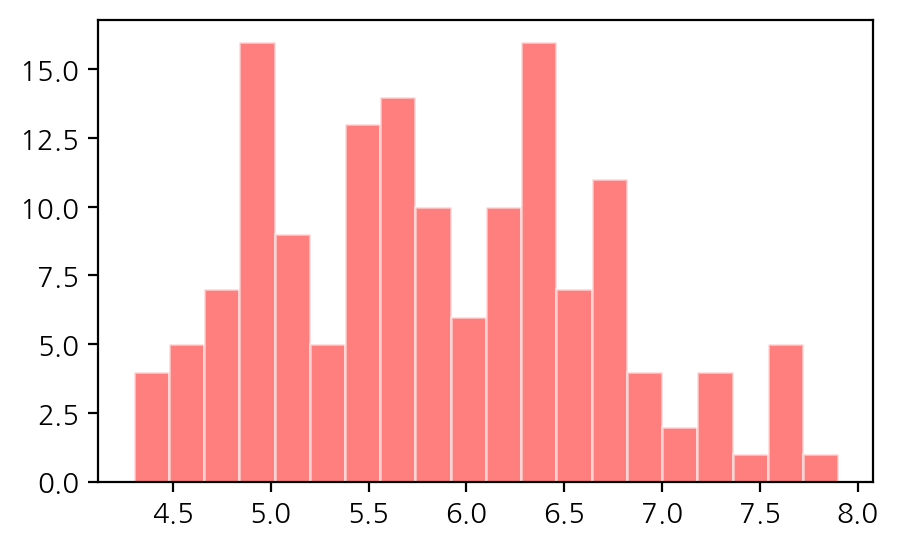

In [76]:
# Sepal.Length 히스토그램
plt.hist(iris['Sepal.Length'], bins=20, color='red', alpha=.5, edgecolor='white')
plt.show()

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


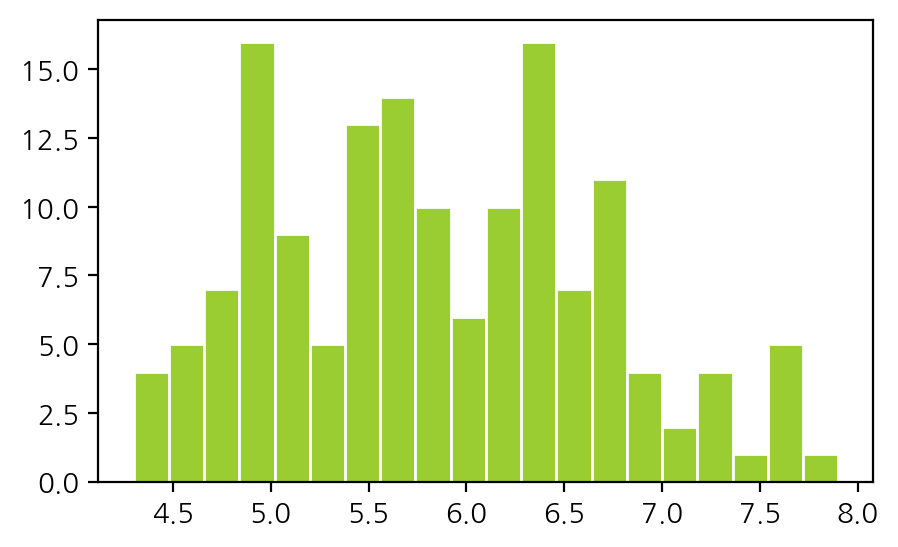

In [77]:
# hist 반환 값 확인
n, bins, patches = plt.hist(iris['Sepal.Length'],
                            bins=20,
                            color='yellowgreen',
                            edgecolor='white')
print(n)
print(bins)
print(patches)
plt.show()

In [78]:
# 빈도수 배열 확인
n

array([ 4.,  5.,  7., 16.,  9.,  5., 13., 14., 10.,  6., 10., 16.,  7.,
       11.,  4.,  2.,  4.,  1.,  5.,  1.])

In [79]:
# 구간 경계 확인
bins

array([4.3 , 4.48, 4.66, 4.84, 5.02, 5.2 , 5.38, 5.56, 5.74, 5.92, 6.1 ,
       6.28, 6.46, 6.64, 6.82, 7.  , 7.18, 7.36, 7.54, 7.72, 7.9 ])

In [80]:
# patches 확인
patches

<BarContainer object of 20 artists>

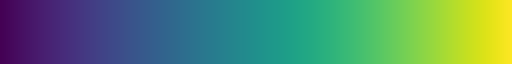

In [81]:
# 색상맵 확인
plt.cm.viridis

In [82]:
# 첫 번째 구간 빈도수
n[0]

np.float64(4.0)

In [83]:
# 최대 빈도수
max(n)

np.float64(16.0)

In [84]:
# 두 번째 구간 빈도 비율
n[1] / max(n)

np.float64(0.3125)

In [85]:
# 색상맵 값 확인
plt.cm.viridis(n[1] / max(n))

(np.float64(0.19943),
 np.float64(0.387607),
 np.float64(0.554642),
 np.float64(1.0))

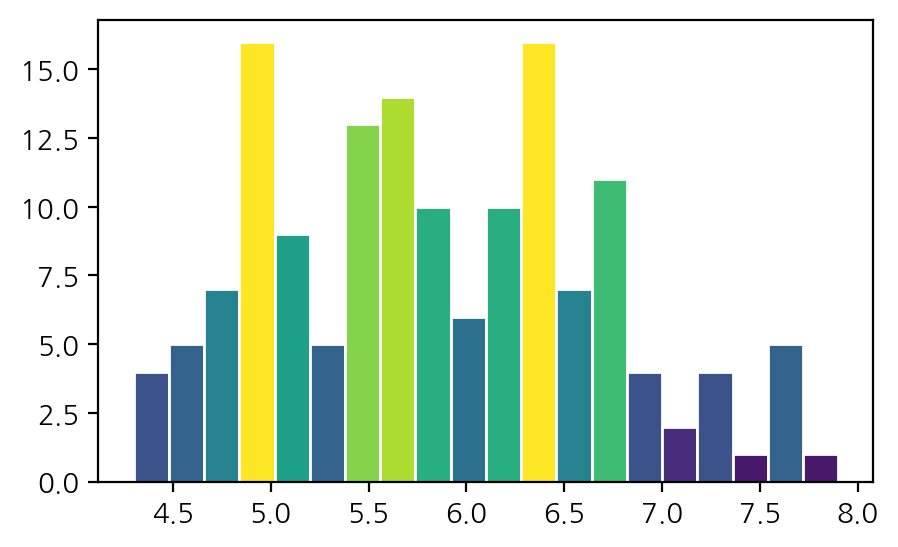

In [86]:
# 빈도수에 따라 막대 색상 변경
n, bins, patches = plt.hist(iris['Sepal.Length'],
                            bins=20,
                            color='red',
                            edgecolor='white')

for i in range(len(patches)):
    patches[i].set_facecolor(plt.cm.viridis(n[i] / max(n)))

plt.show()

### 커널 밀도 추정과 seaborn 분포 시각화

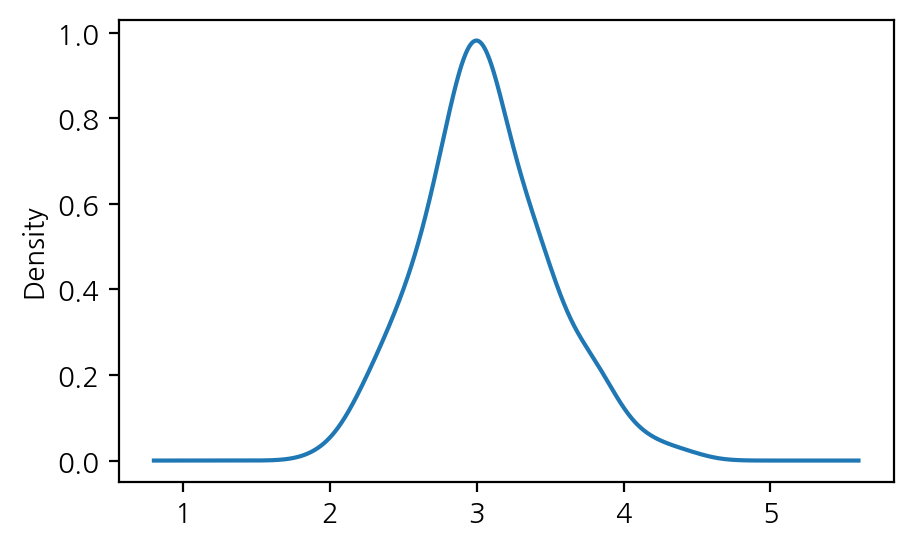

In [87]:
# 밀도 그래프
iris['Sepal.Width'].plot.density()
plt.show()

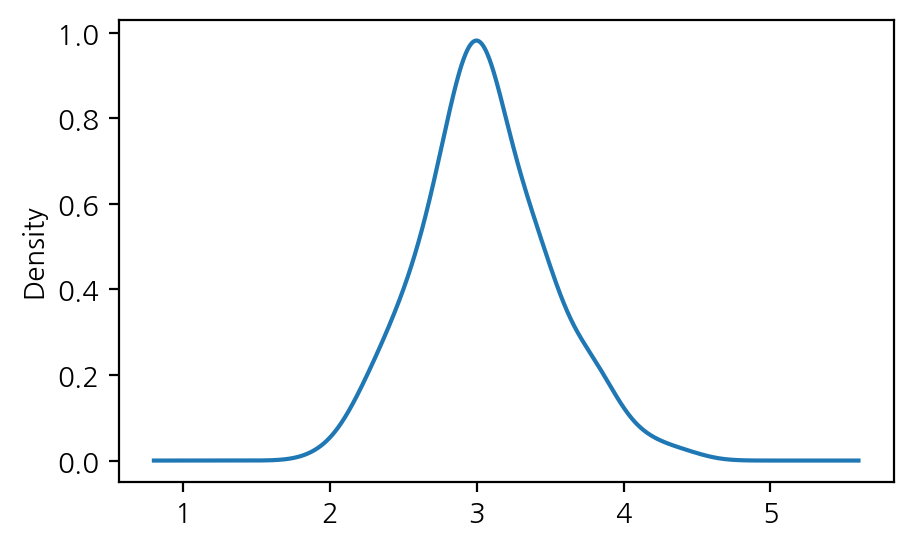

In [88]:
# kde 그래프
iris['Sepal.Width'].plot.kde()
plt.show()

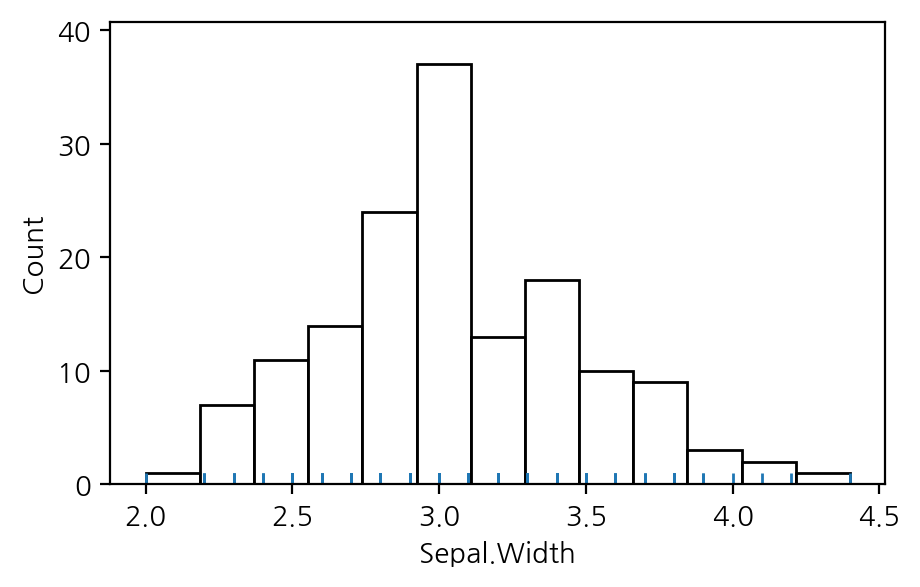

In [89]:
# histplot과 rugplot
sns.histplot(data=iris, x=iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x=iris['Sepal.Width'])
plt.show()

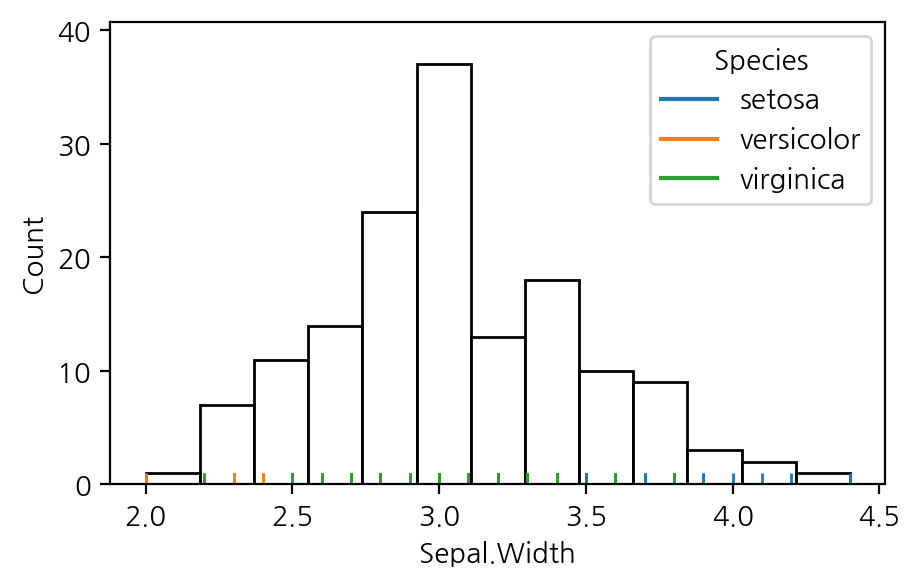

In [90]:
# 품종에 따른 rugplot
sns.histplot(data=iris, x=iris['Sepal.Width'], color='white')
sns.rugplot(data=iris, x=iris['Sepal.Width'], hue='Species')
plt.show()

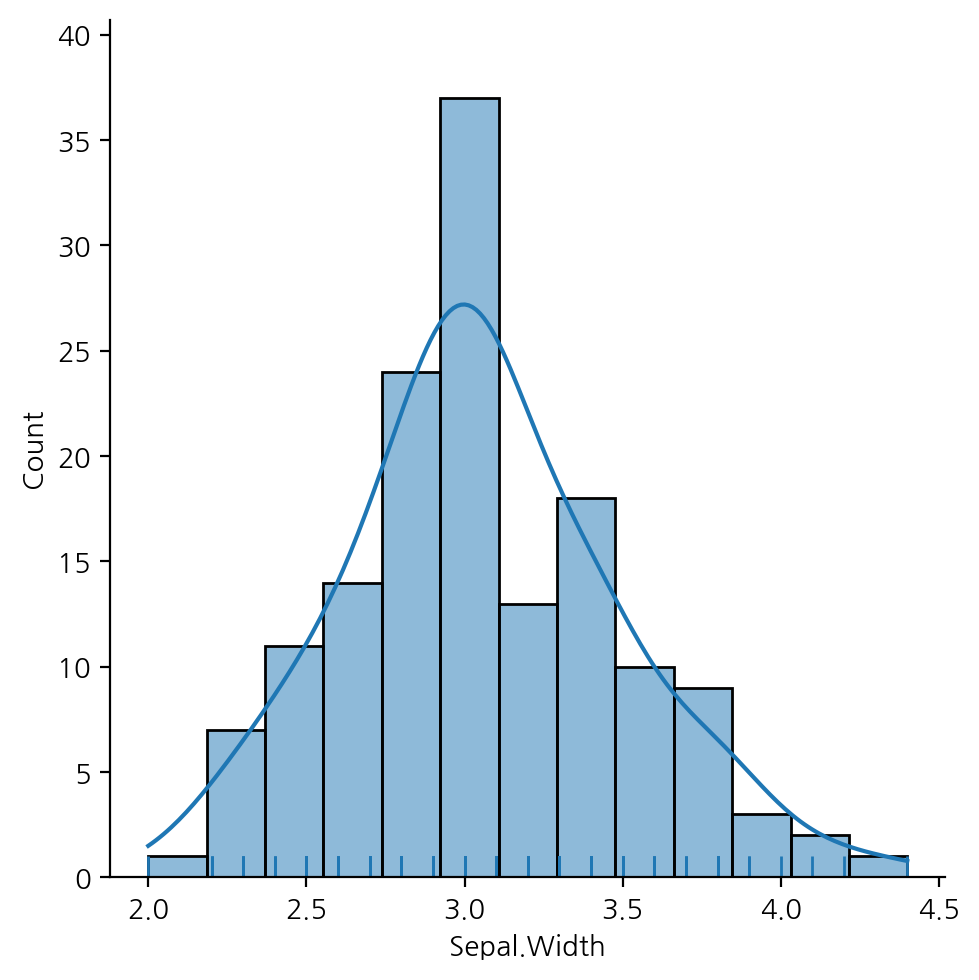

In [91]:
# displot: 히스토그램 + kde + rug
sns.displot(data=iris, x=iris['Sepal.Width'], kde=True, rug=True)
plt.show()

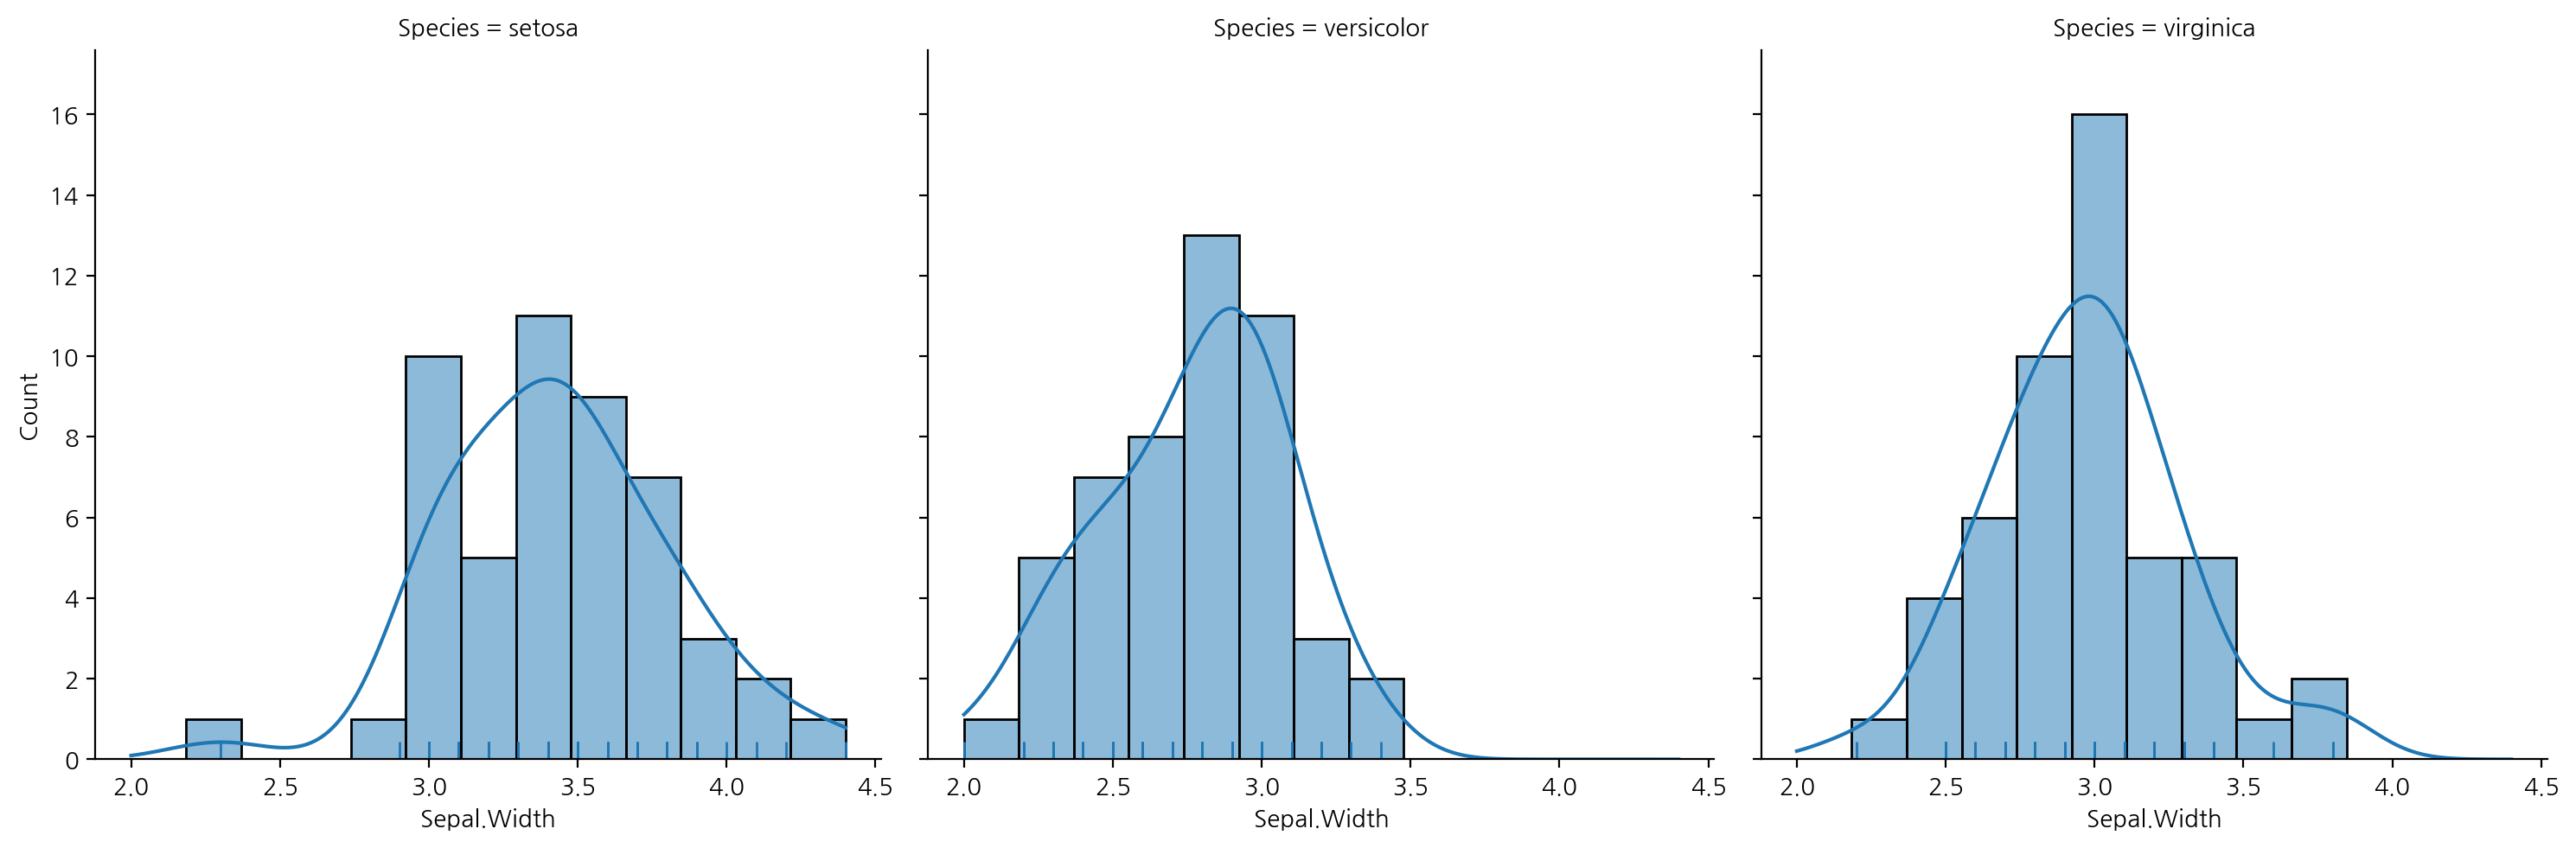

In [92]:
# 품종별 분포
sns.displot(data=iris, x=iris['Sepal.Width'], col="Species",
            kde=True, rug=True)
plt.show()

### 파이 차트

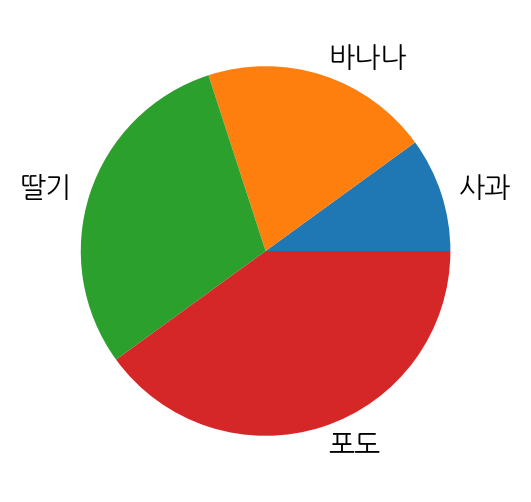

In [93]:
# 기본 파이 차트
fruits = ['사과', '바나나', '딸기', '포도']
plt.pie([10, 20, 30, 40], labels=fruits)
plt.show()

In [94]:
# cyl 빈도수 확인
mtc.cyl.value_counts().sort_index()

,count
cyl,
4,11
6,7
8,14


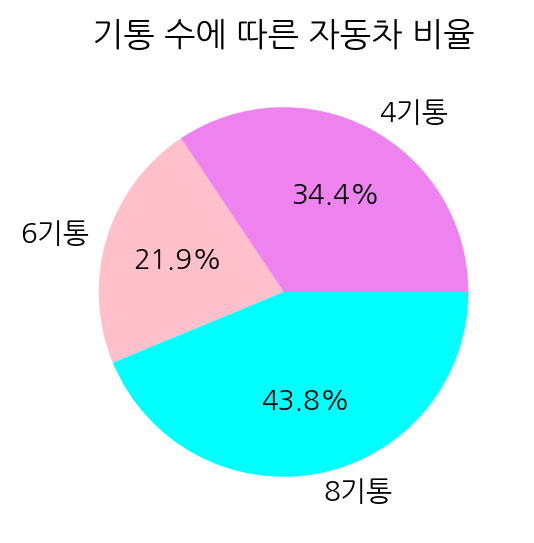

In [95]:
# cyl 파이 차트
txt = ['4기통', '6기통', '8기통']

plt.pie(mtc.cyl.value_counts().sort_index(),
        colors=["violet", "pink", "aqua"],
        autopct='%.1f%%',
        labels=txt)

plt.title("기통 수에 따른 자동차 비율")
plt.show()

In [96]:
# gear 빈도수 확인
mtc.gear.value_counts().sort_index()

,count
gear,
3,15
4,12
5,5


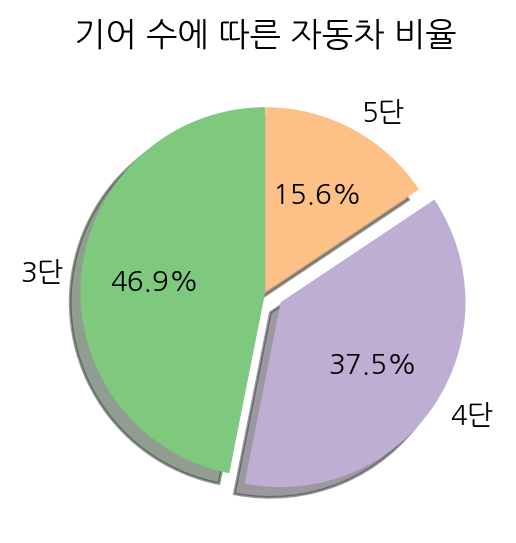

In [97]:
# gear 파이 차트
labels = ['3단', '4단', '5단']
colors = sns.color_palette('Accent', len(labels))

plt.pie(mtc.gear.value_counts().sort_index(),
        colors=colors,
        explode=[0, .1, 0],
        shadow=True,
        startangle=90,
        autopct='%.1f%%',
        labels=labels)

plt.title("기어 수에 따른 자동차 비율")
plt.show()

## 9.3 바이올린과 상관관계 시각화

### 바이올린 플롯

In [98]:
# 정규분포 난수 생성
np.random.seed(1)
vdata = np.random.normal(0, 1, 2000)

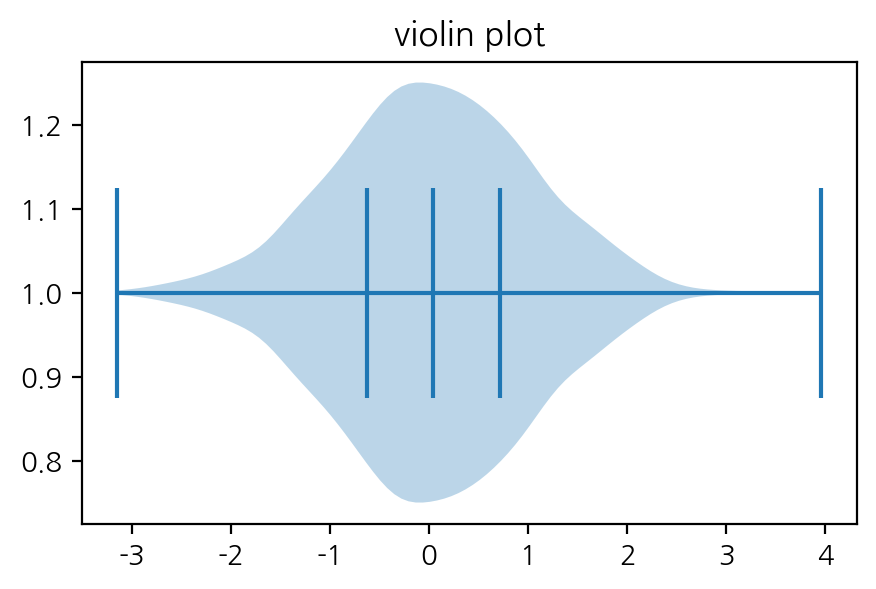

In [99]:
# matplotlib violinplot
plt.violinplot(vdata, vert=False, quantiles=[.25, .5, .75])
plt.title('violin plot')
plt.show()

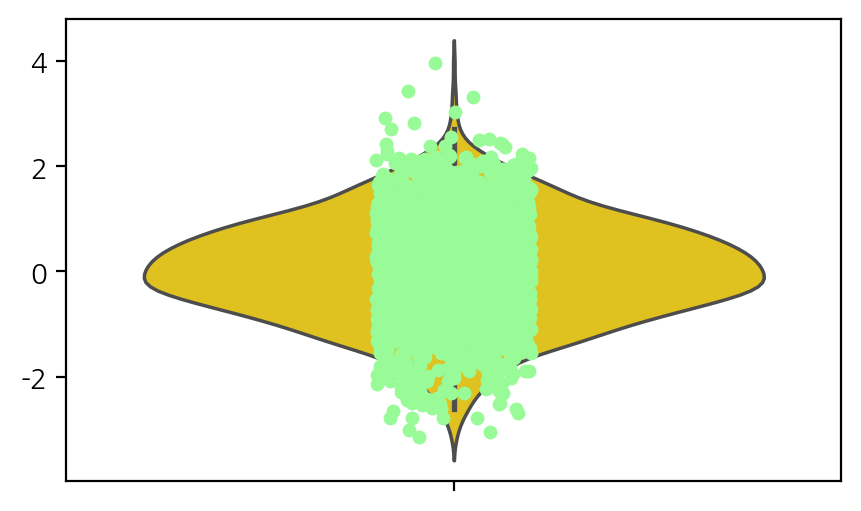

In [100]:
# seaborn violinplot
sns.violinplot(data=vdata, color='gold')
sns.stripplot(data=vdata, color='palegreen')
plt.show()

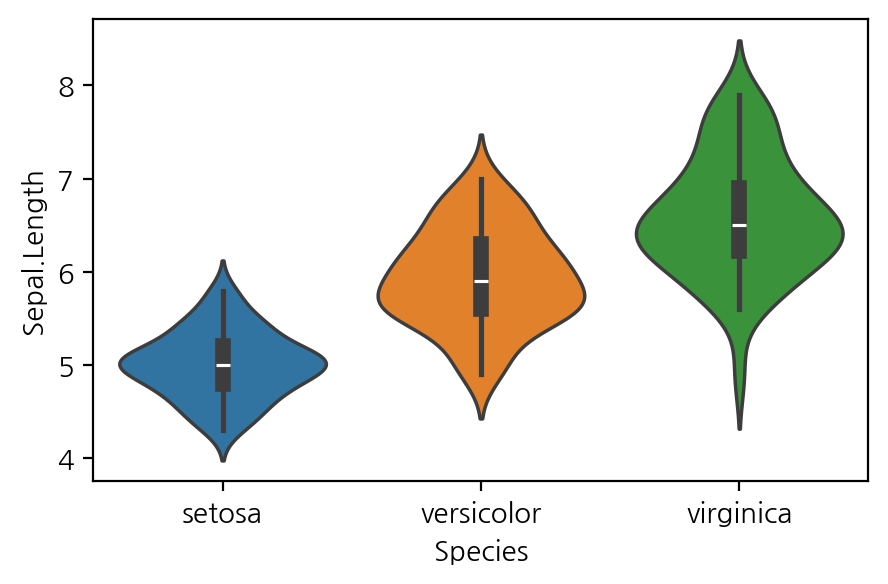

In [101]:
# iris 품종별 Sepal.Length 바이올린 플롯
sns.violinplot(data=iris, x='Species', y='Sepal.Length', hue='Species')
plt.show()

### pairplot과 상관관계

In [102]:
# mtcars 앞부분 4개 변수 추출
mincars = mtc[['mpg', 'cyl', 'disp', 'hp']]
mincars.head()

,mpg,cyl,disp,hp
Mazda RX4,21.0,6,160.0,110
Mazda RX4 Wag,21.0,6,160.0,110
Datsun 710,22.8,4,108.0,93
Hornet 4 Drive,21.4,6,258.0,110
Hornet Sportabout,18.7,8,360.0,175


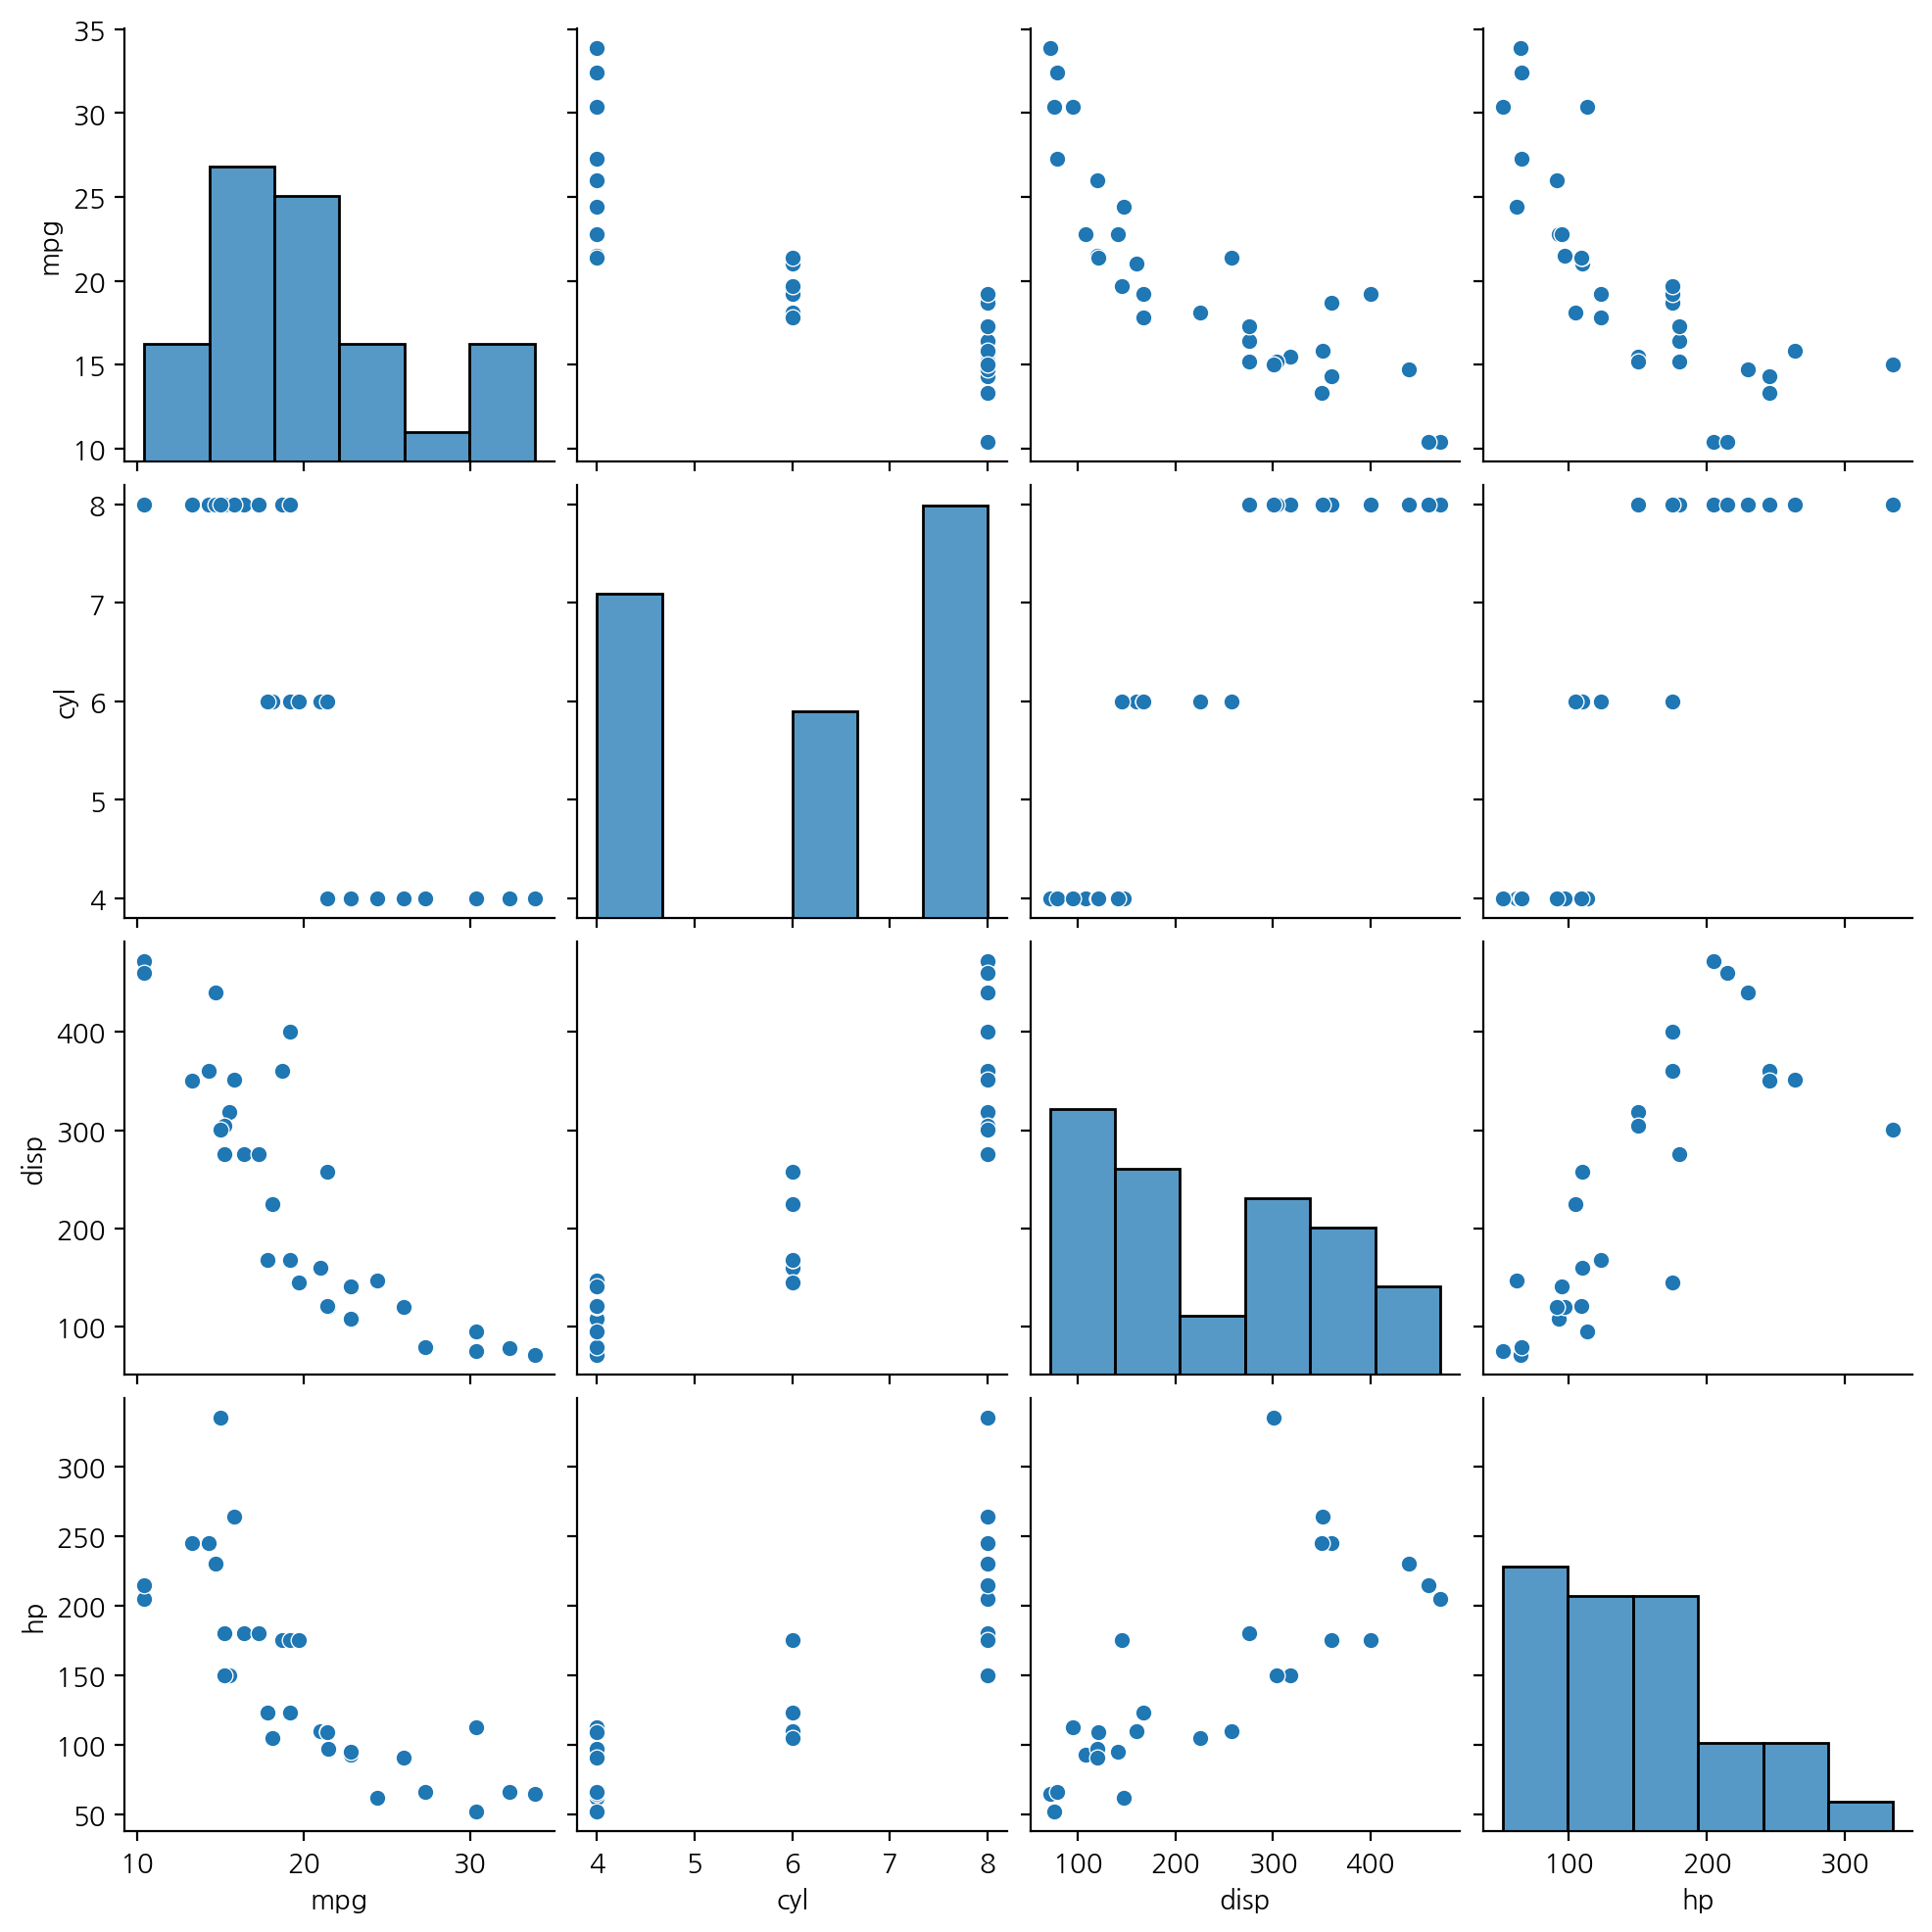

In [103]:
# 기본 pairplot
sns.pairplot(mincars)
plt.show()

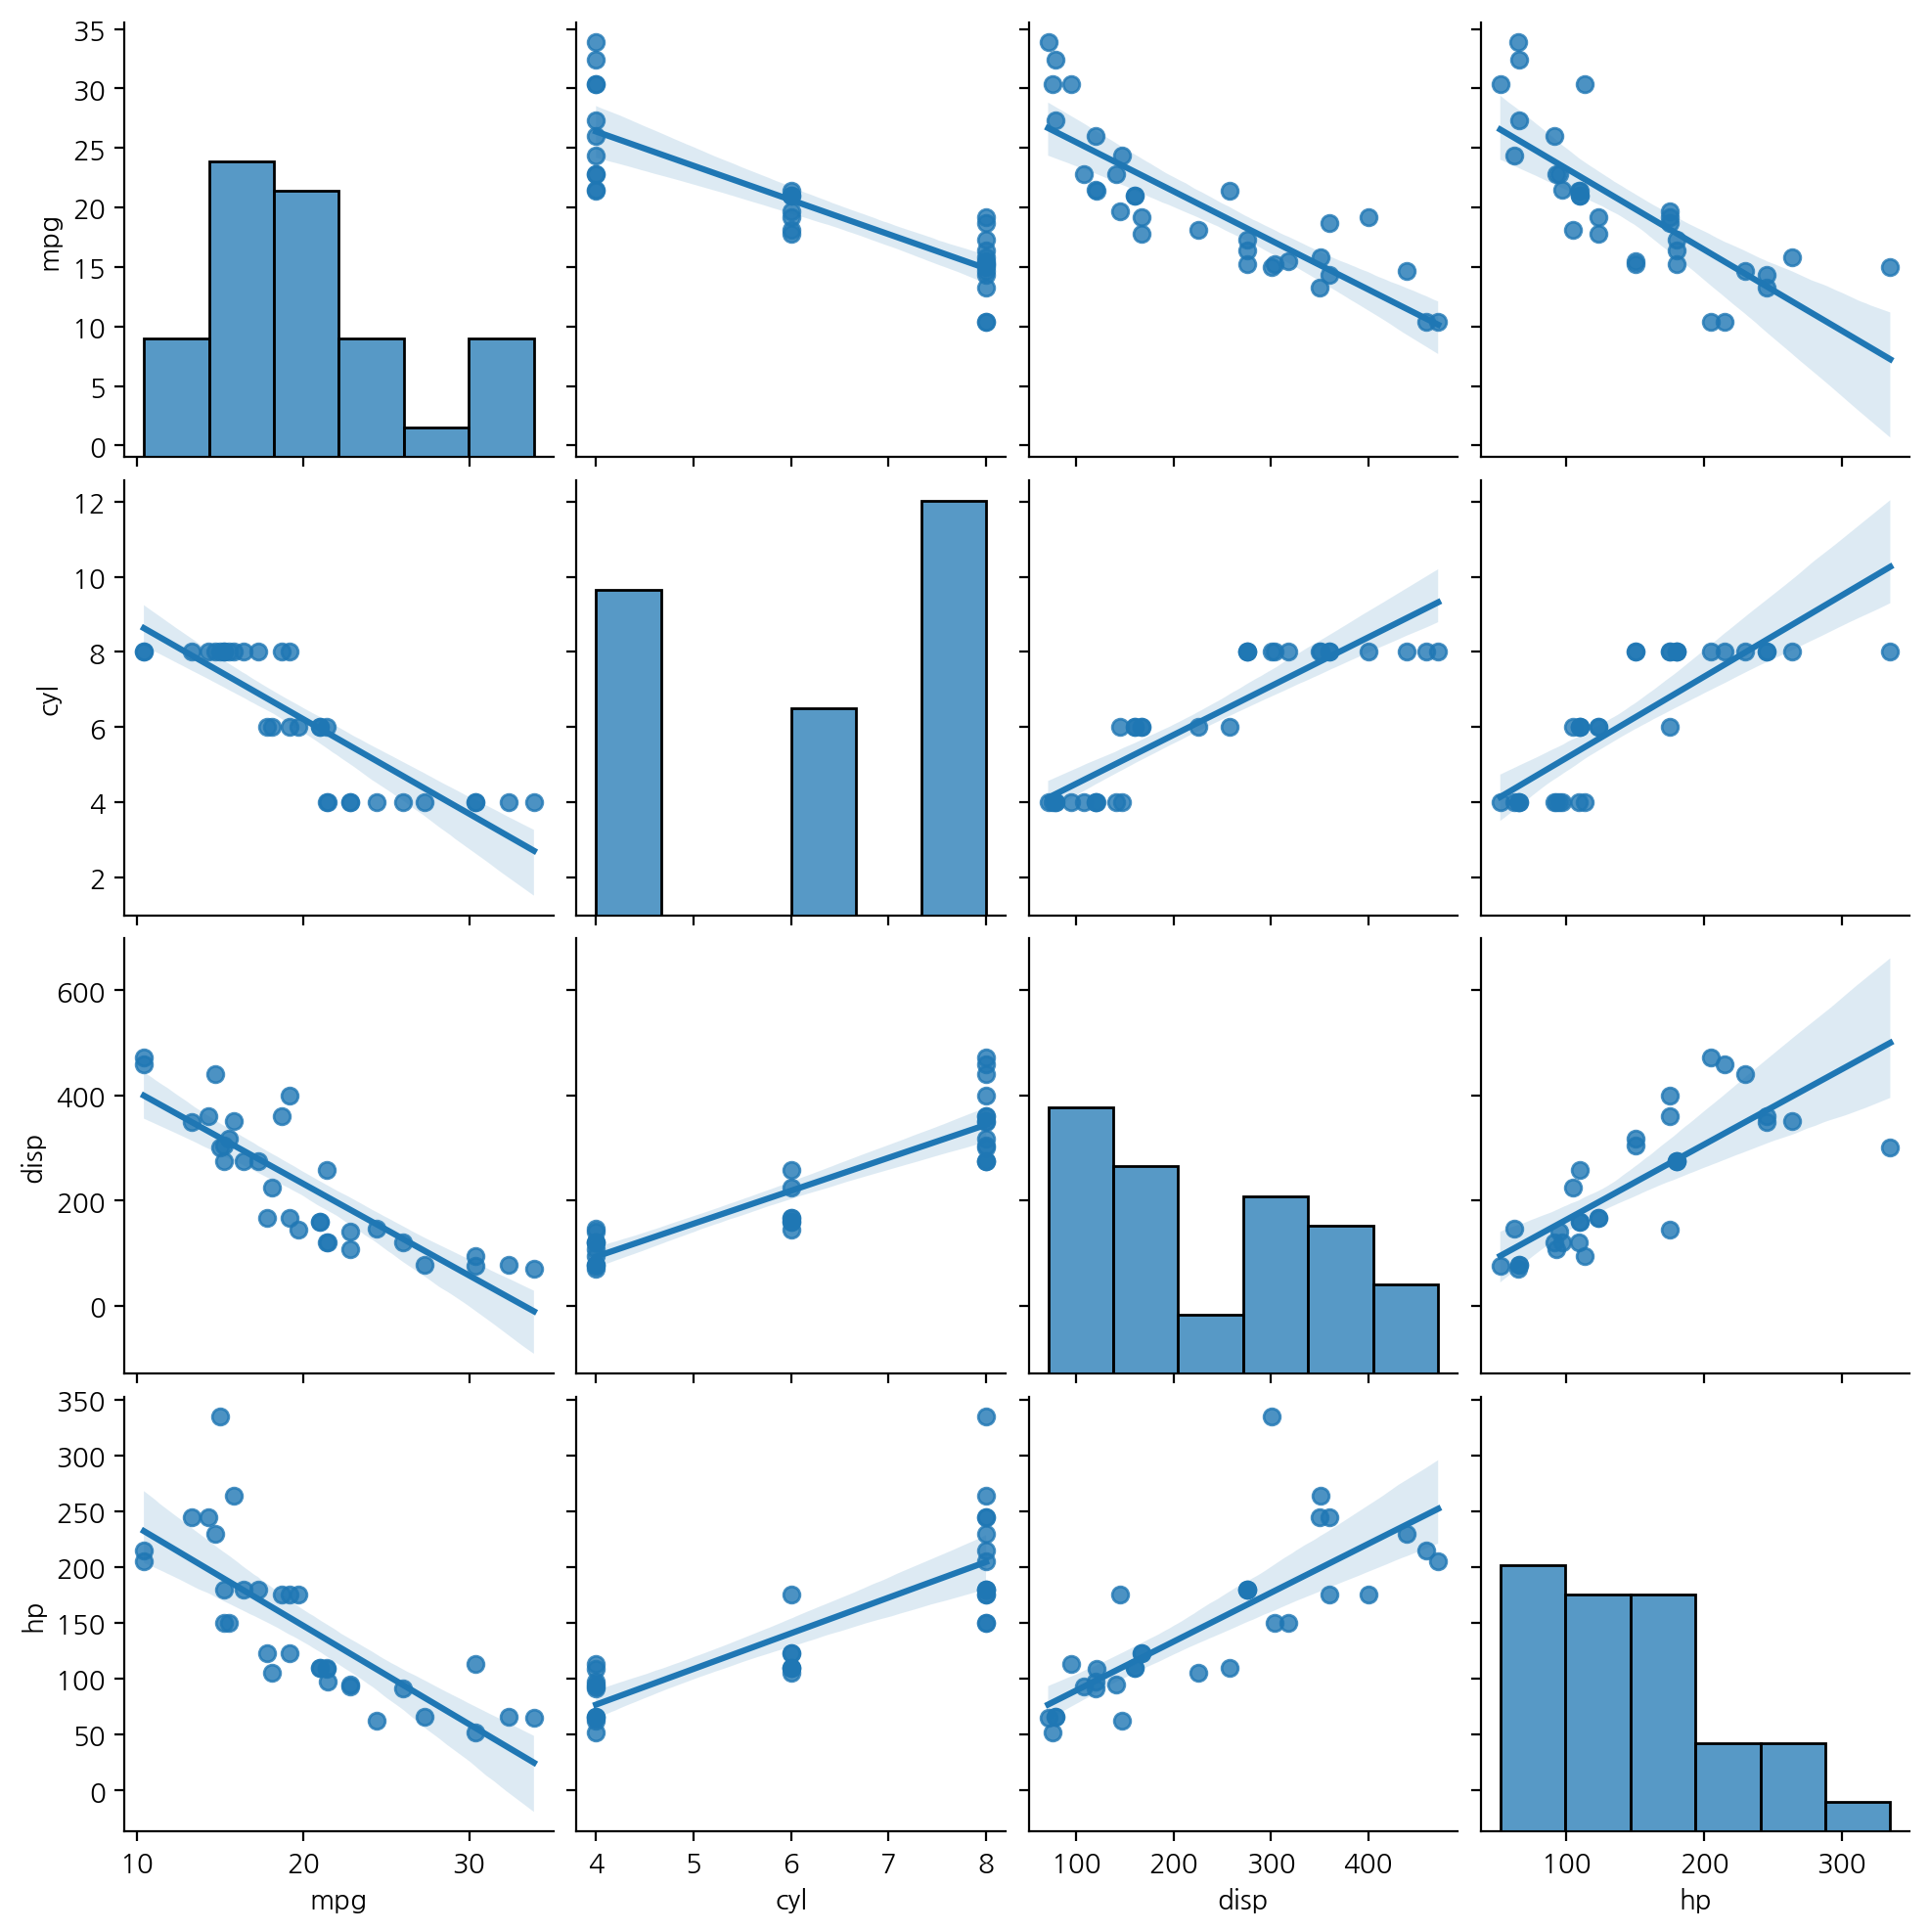

In [104]:
# 회귀선 포함 pairplot
sns.pairplot(mincars, kind='reg')
plt.show()

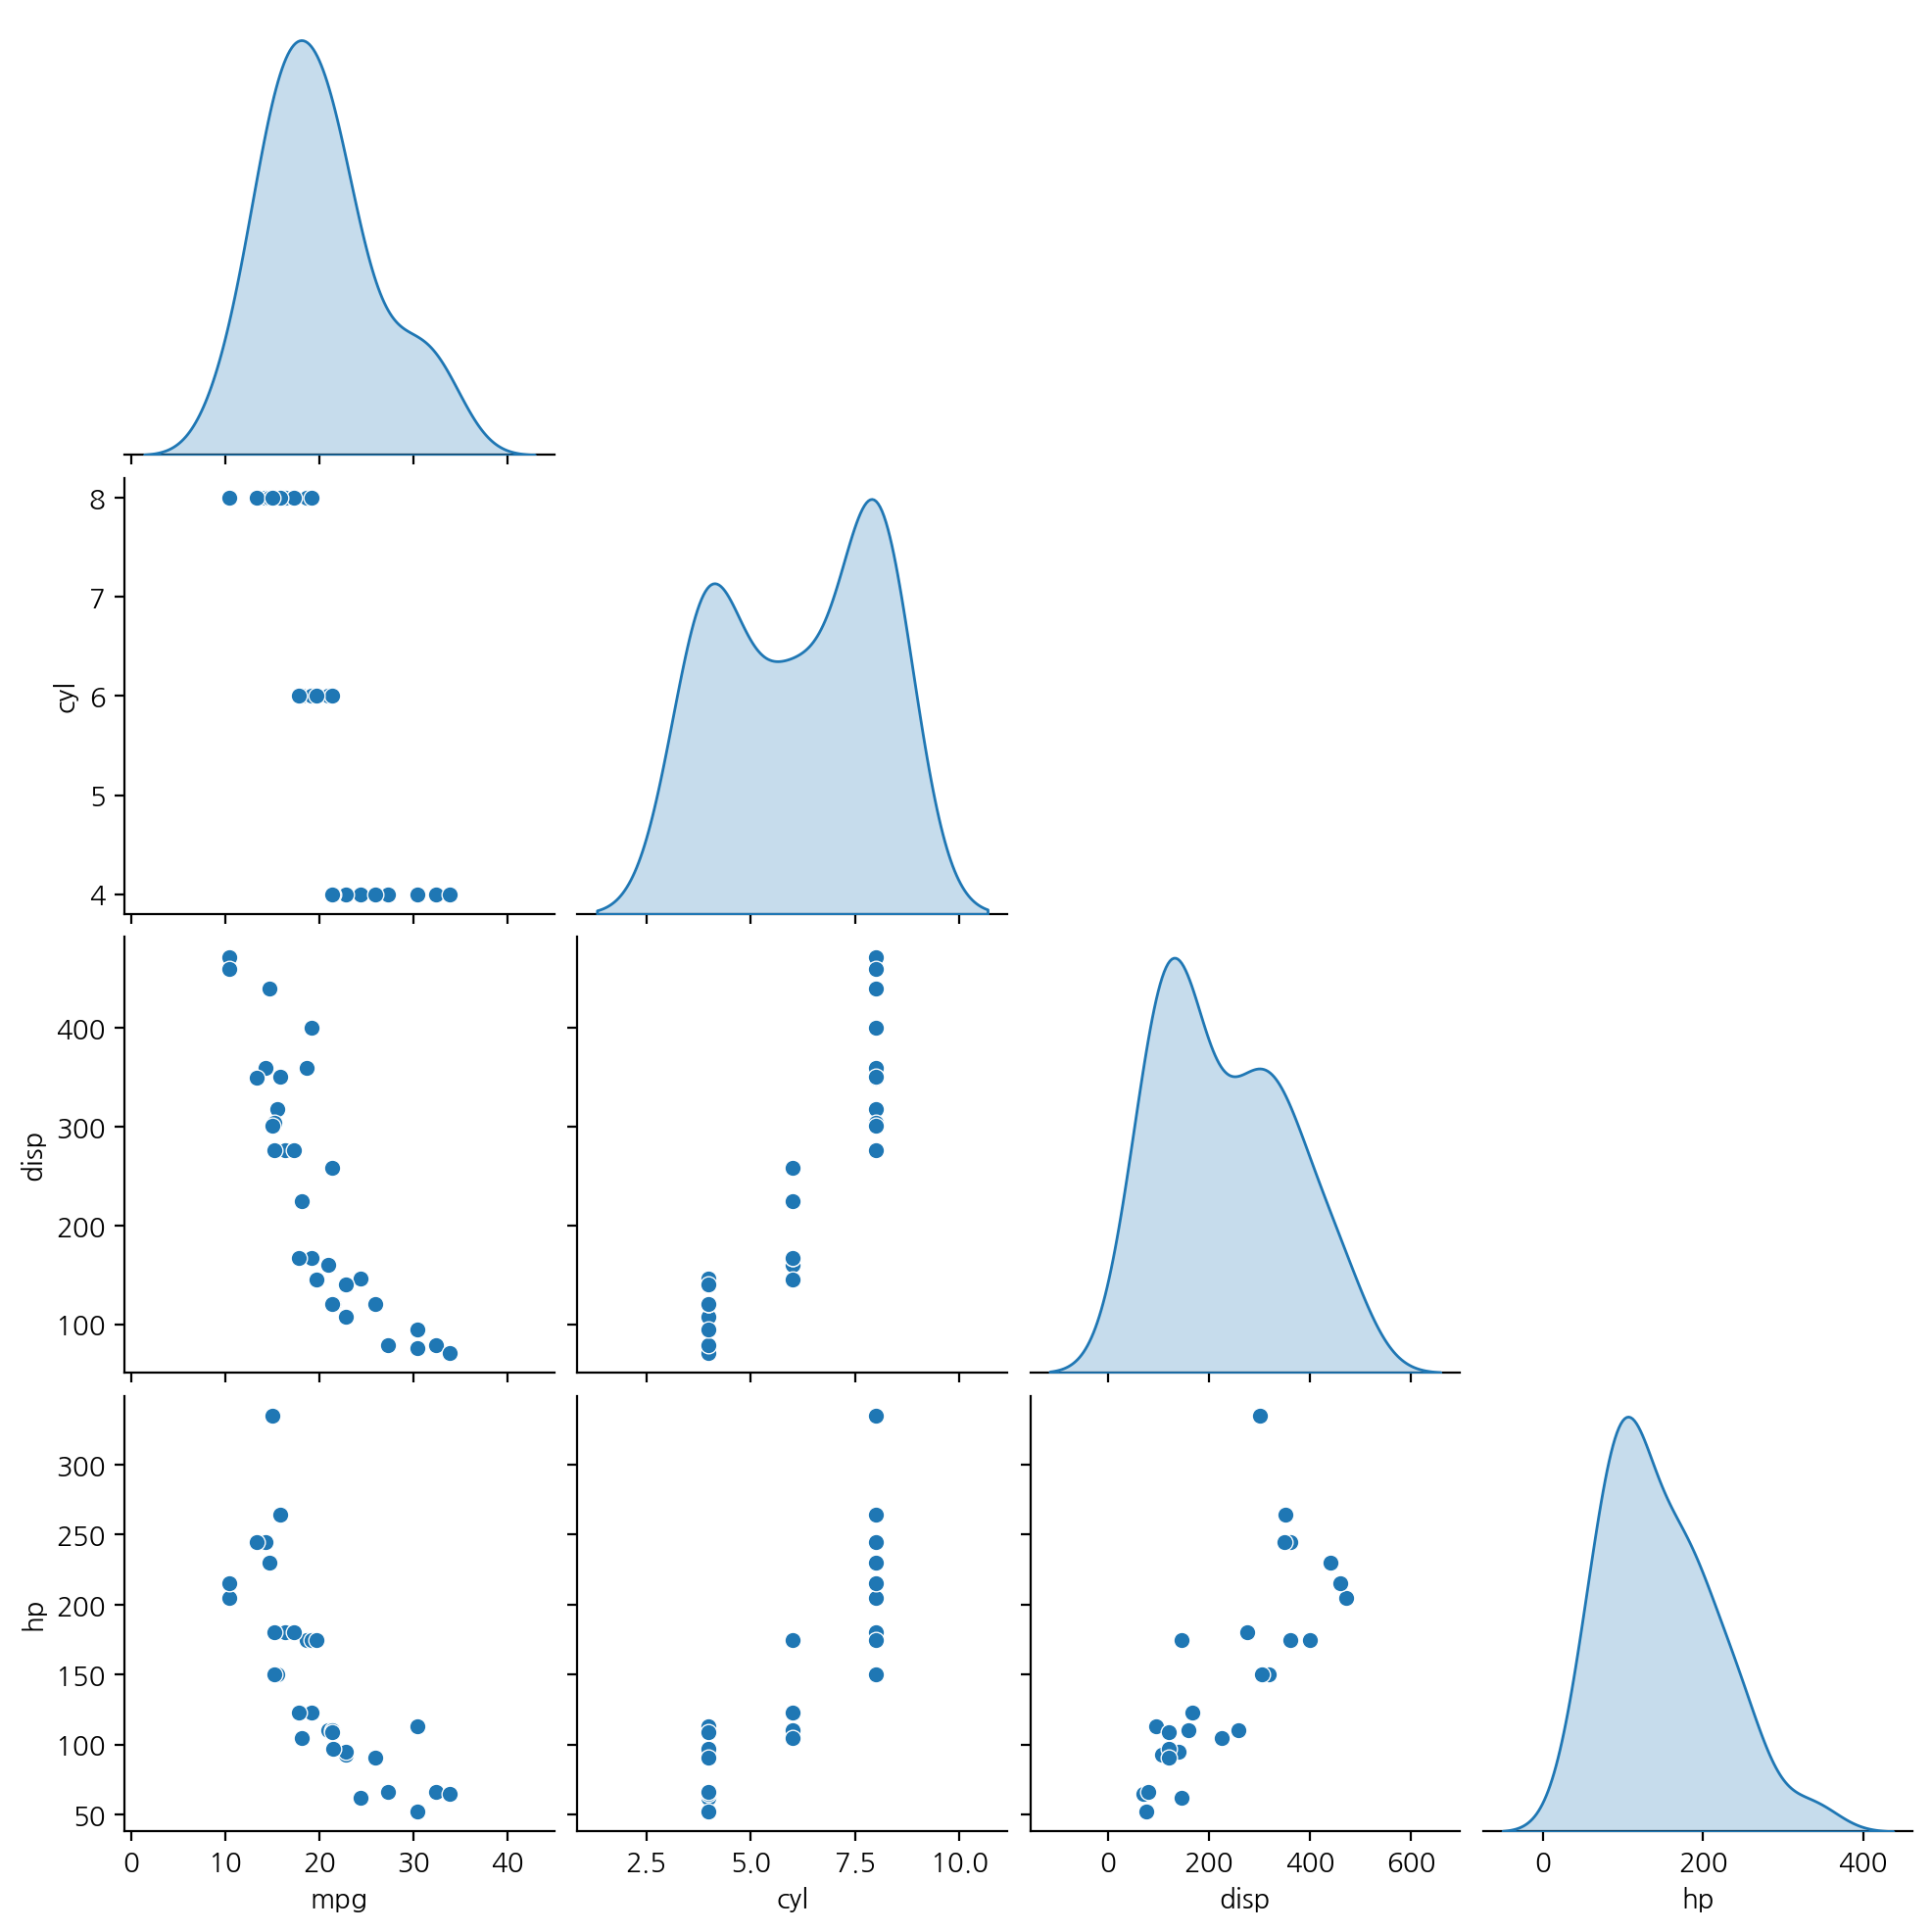

In [105]:
# 대각선 kde, 좌측 하단만 표시
sns.pairplot(mincars, diag_kind='kde', corner=True)
plt.show()

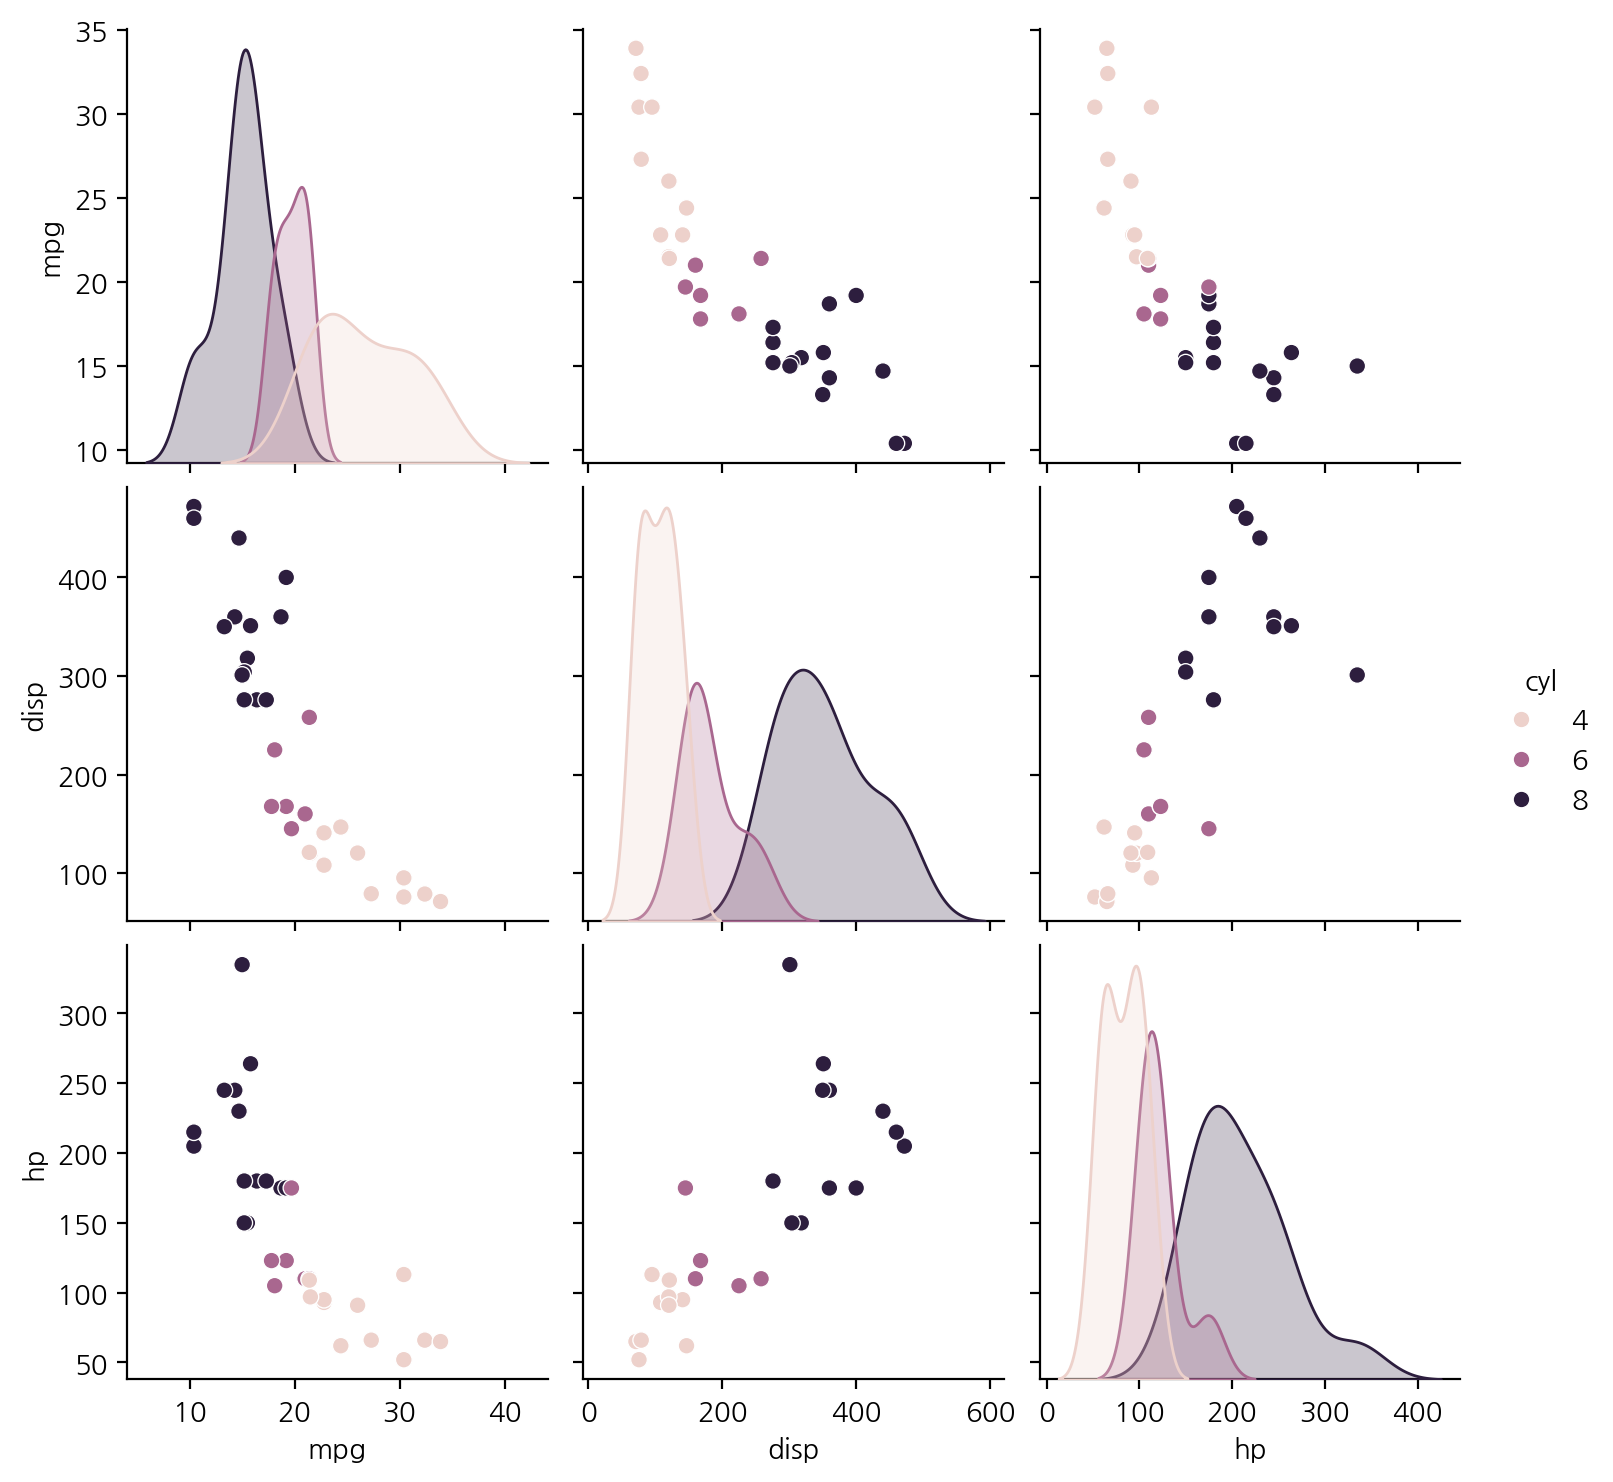

In [106]:
# cyl을 색상으로 구분
sns.pairplot(mincars, hue='cyl', diag_kind='kde')
plt.show()

### seaborn iris와 상관관계 히트맵

In [107]:
# seaborn iris 데이터
iris_sns = sns.load_dataset('iris')
iris_sns.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [108]:
# 숫자형 열만 선택
iris_num = iris_sns.select_dtypes(include='number')
iris_num.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [109]:
# 상관관계 데이터프레임
corr_iris = iris_num.corr()
corr_iris

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


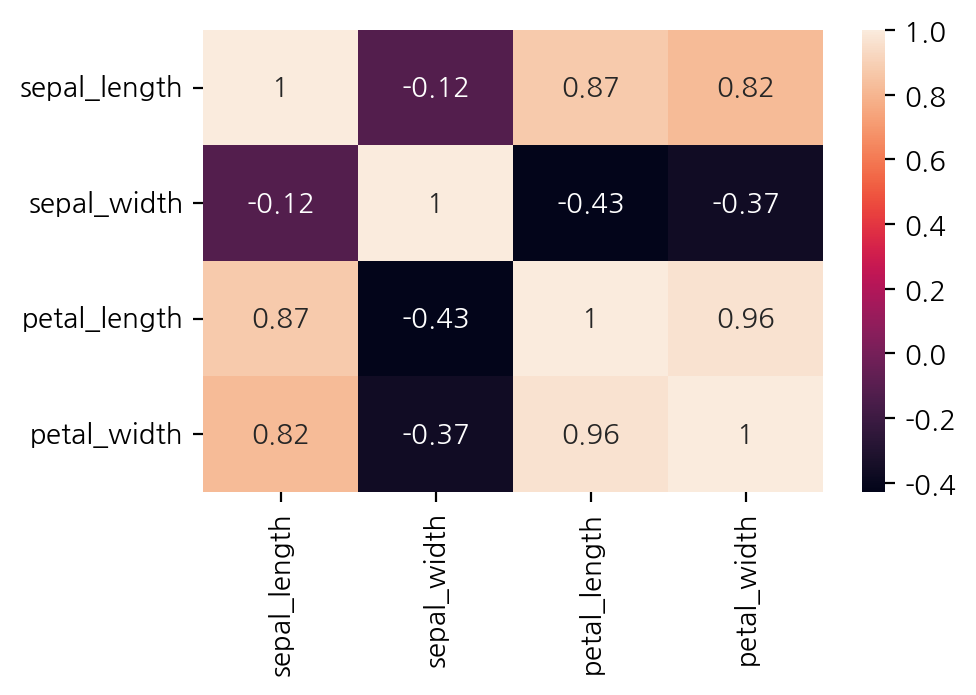

In [110]:
# 기본 히트맵
sns.heatmap(corr_iris, annot=True)
plt.show()

In [111]:
# 마스크 생성
mask = np.zeros_like(corr_iris)
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [112]:
# 첫 행과 마지막 열 제거
mask_new = mask[1:, :-1]
corr_iris_new = corr_iris.iloc[1:, :-1]

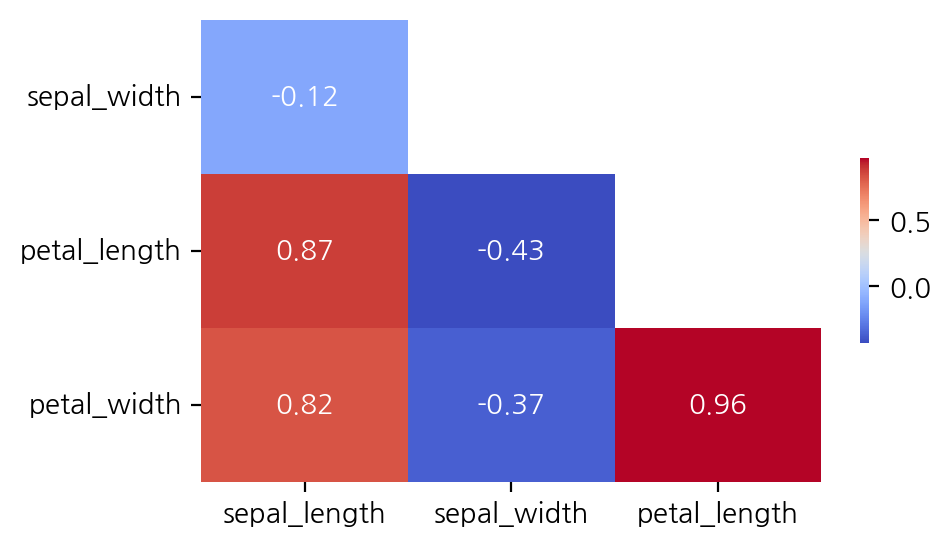

In [113]:
# 좌측 하단 삼각 행렬 히트맵
sns.heatmap(corr_iris_new,
            mask=mask_new,
            annot=True,
            cmap='coolwarm',
            cbar_kws={'shrink': .4})

plt.show()

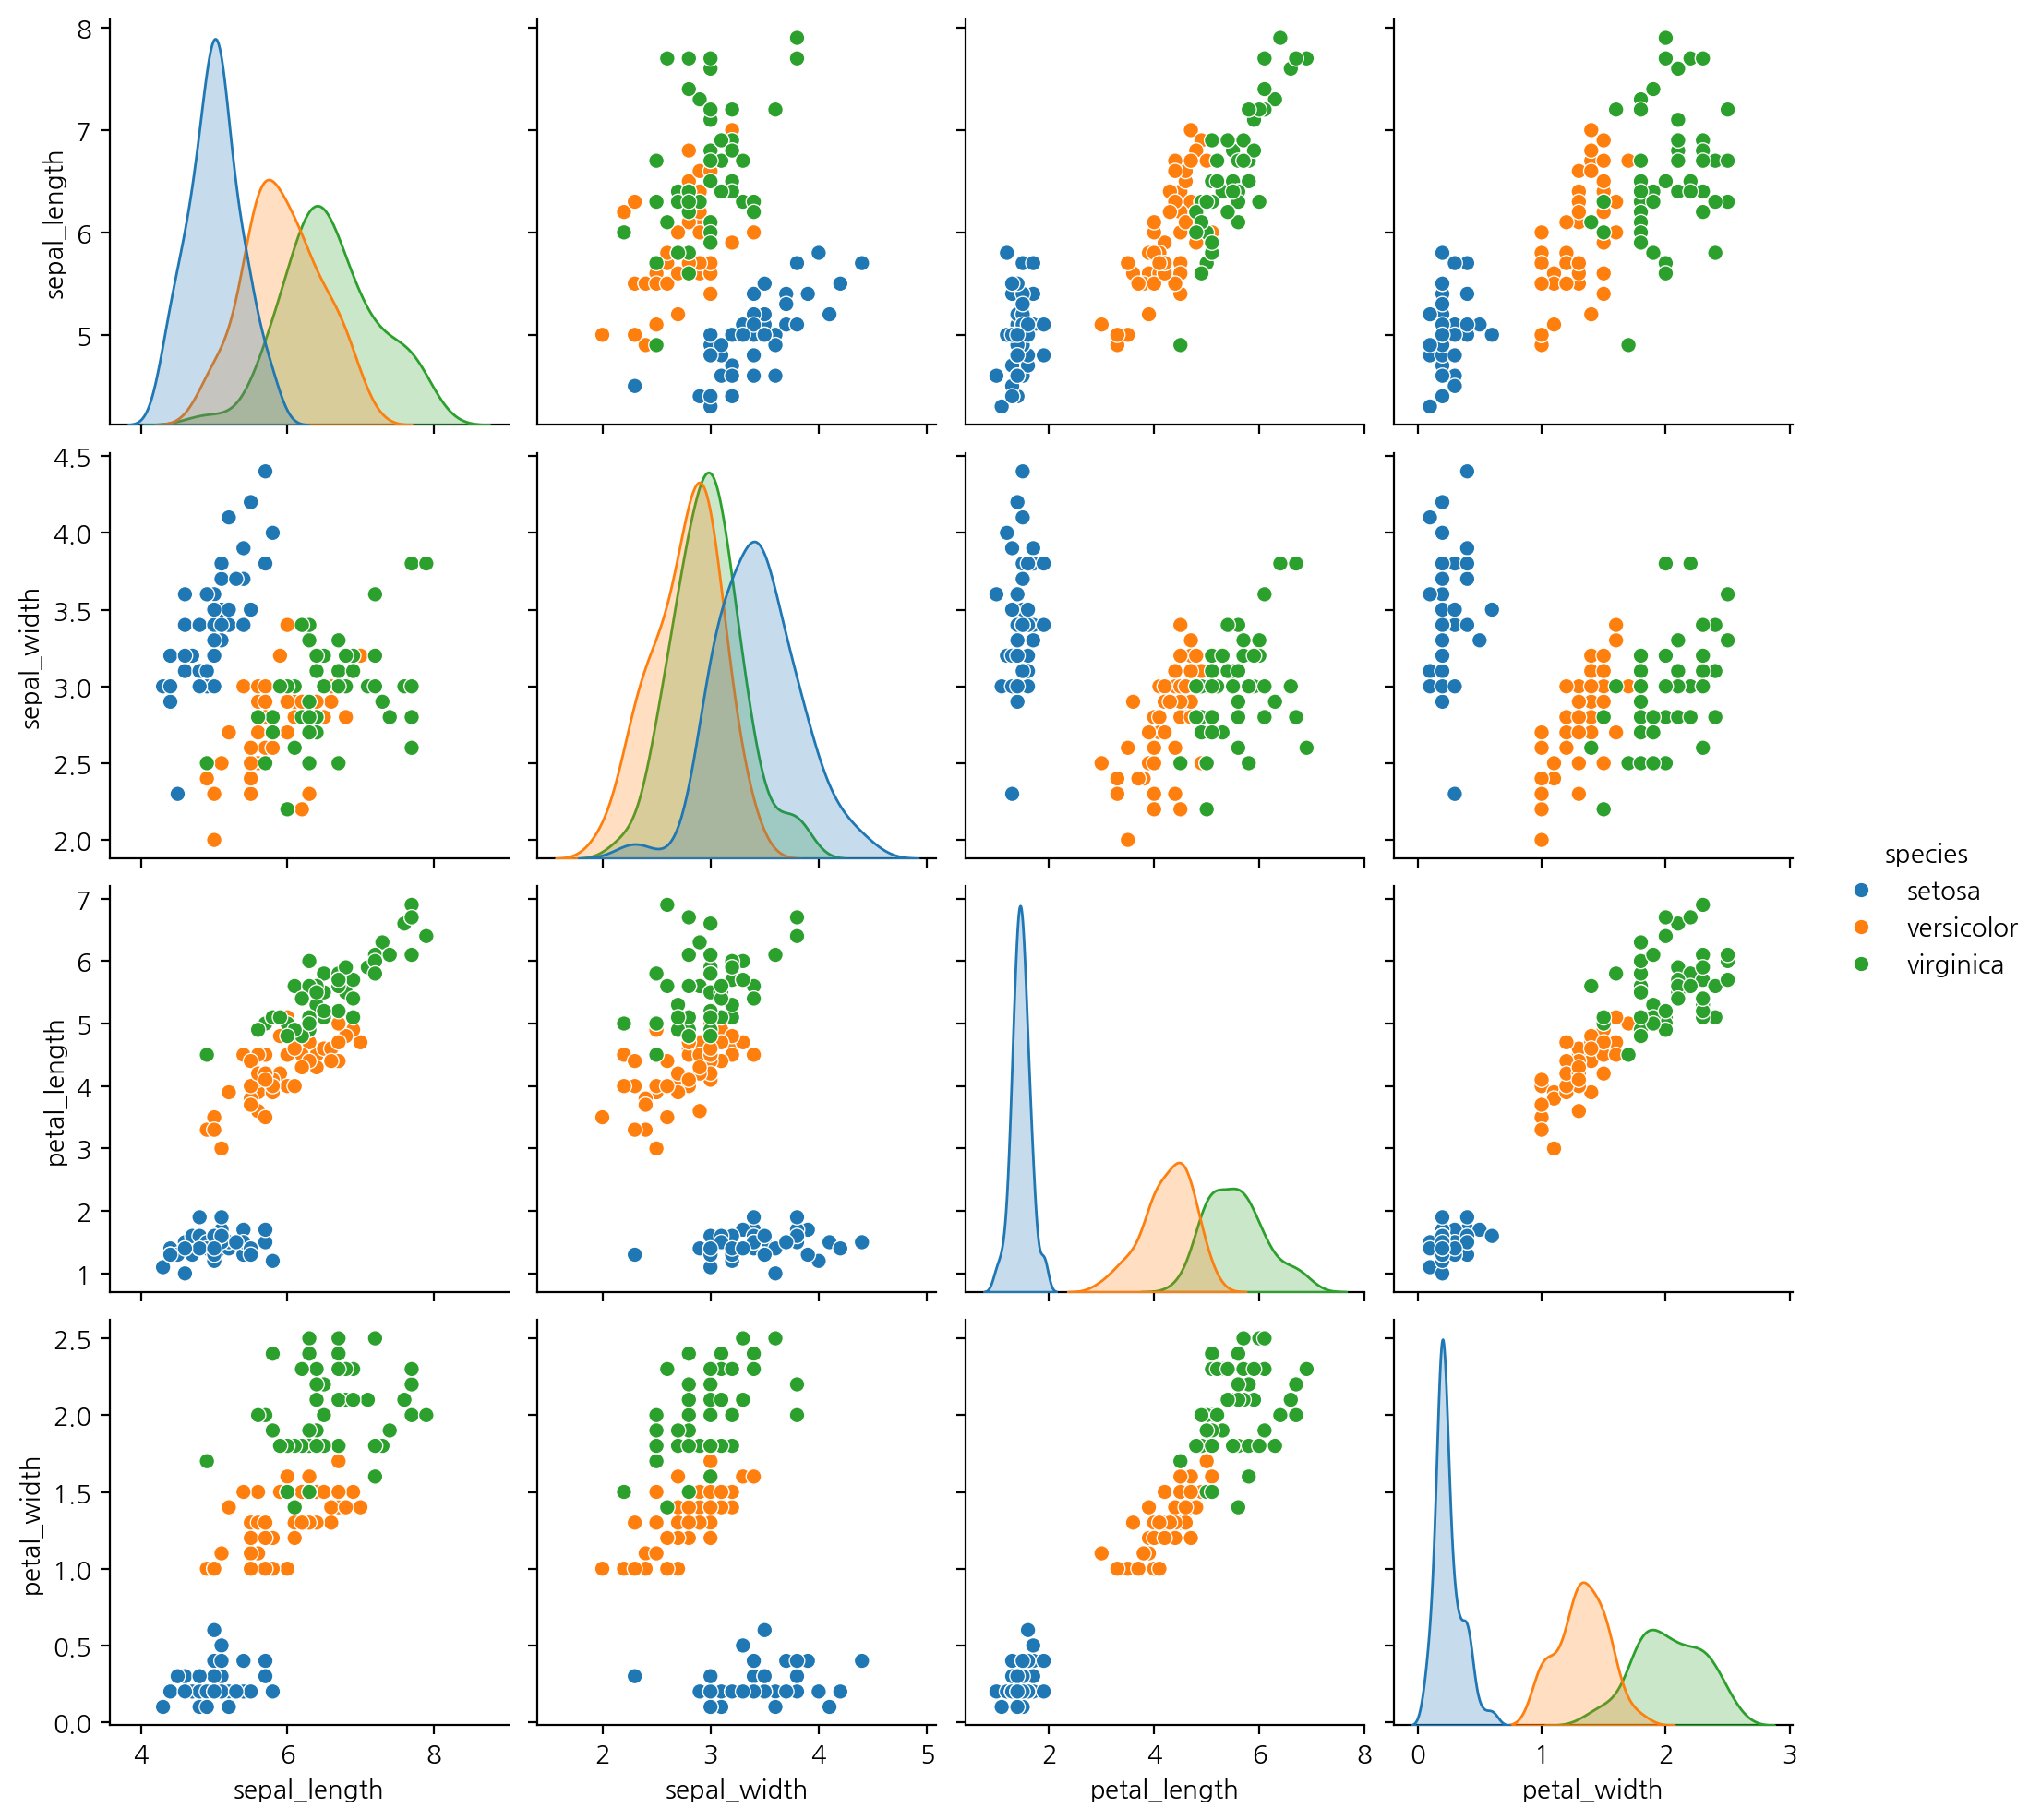

In [114]:
# iris pairplot
sns.pairplot(iris_sns, hue='species')
plt.show()

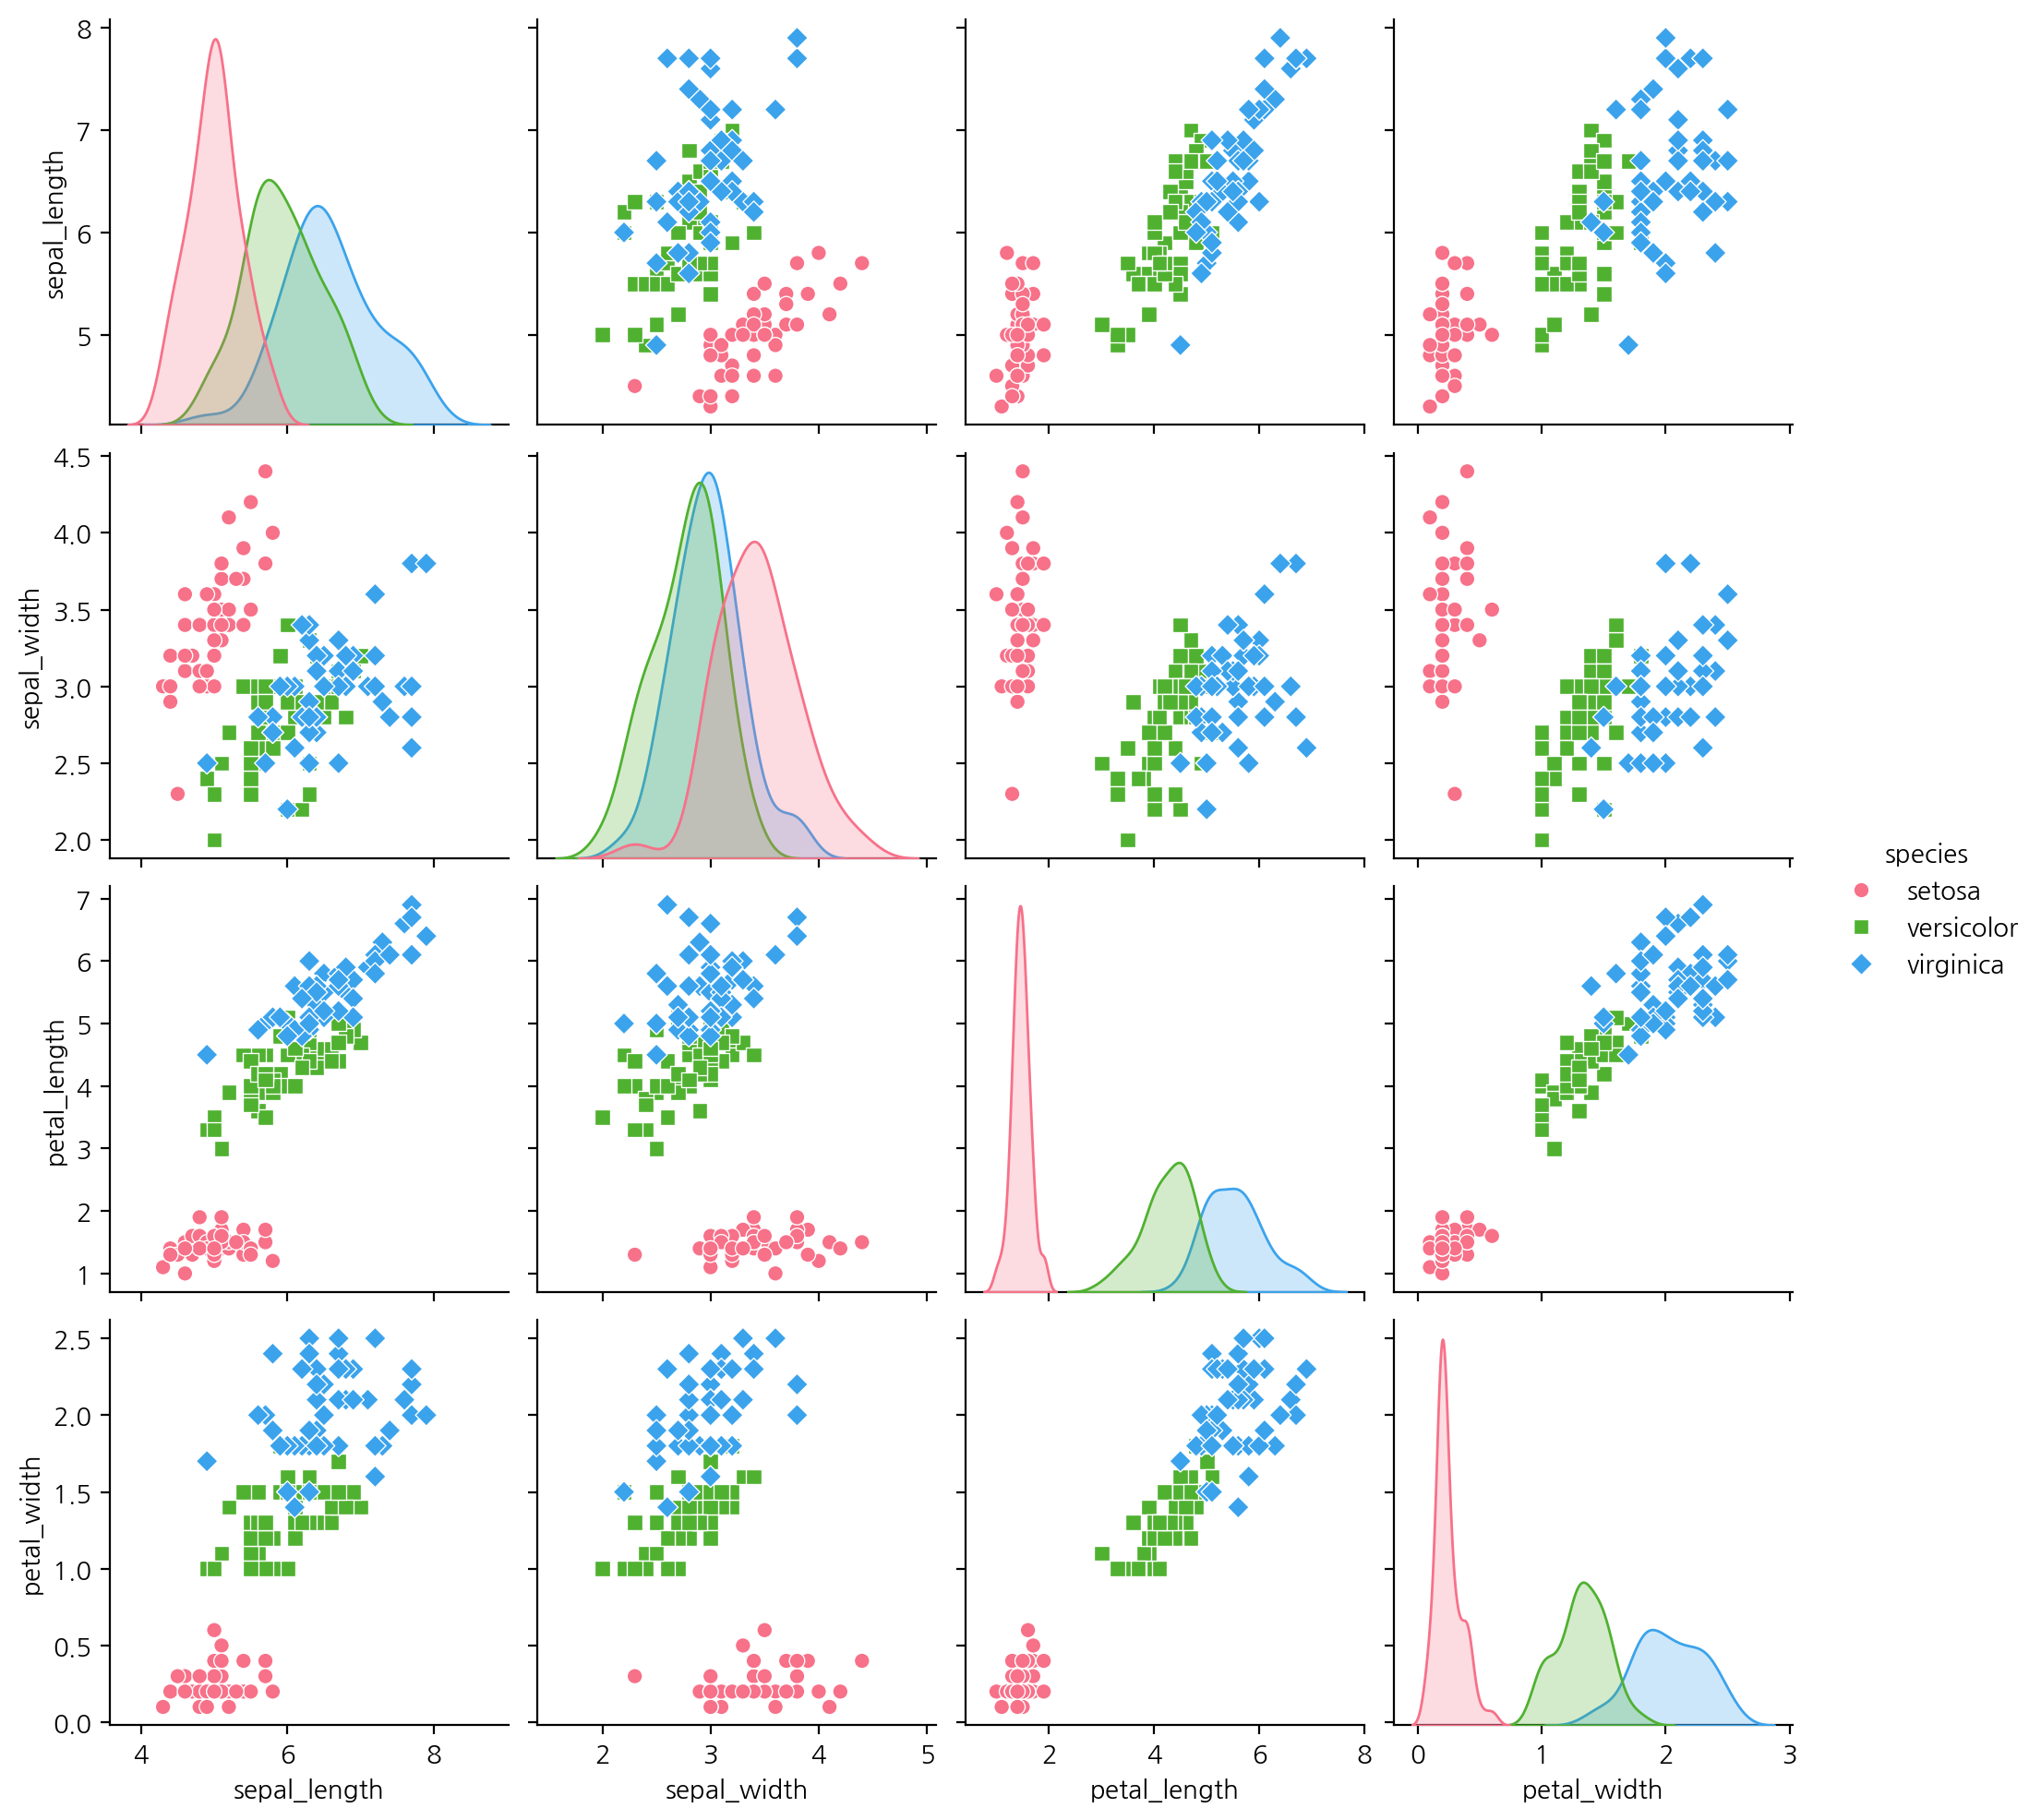

In [115]:
# 색상과 마커 지정
sns.pairplot(iris_sns, hue="species",
             palette="husl",
             markers=["o", "s", "D"])
plt.show()

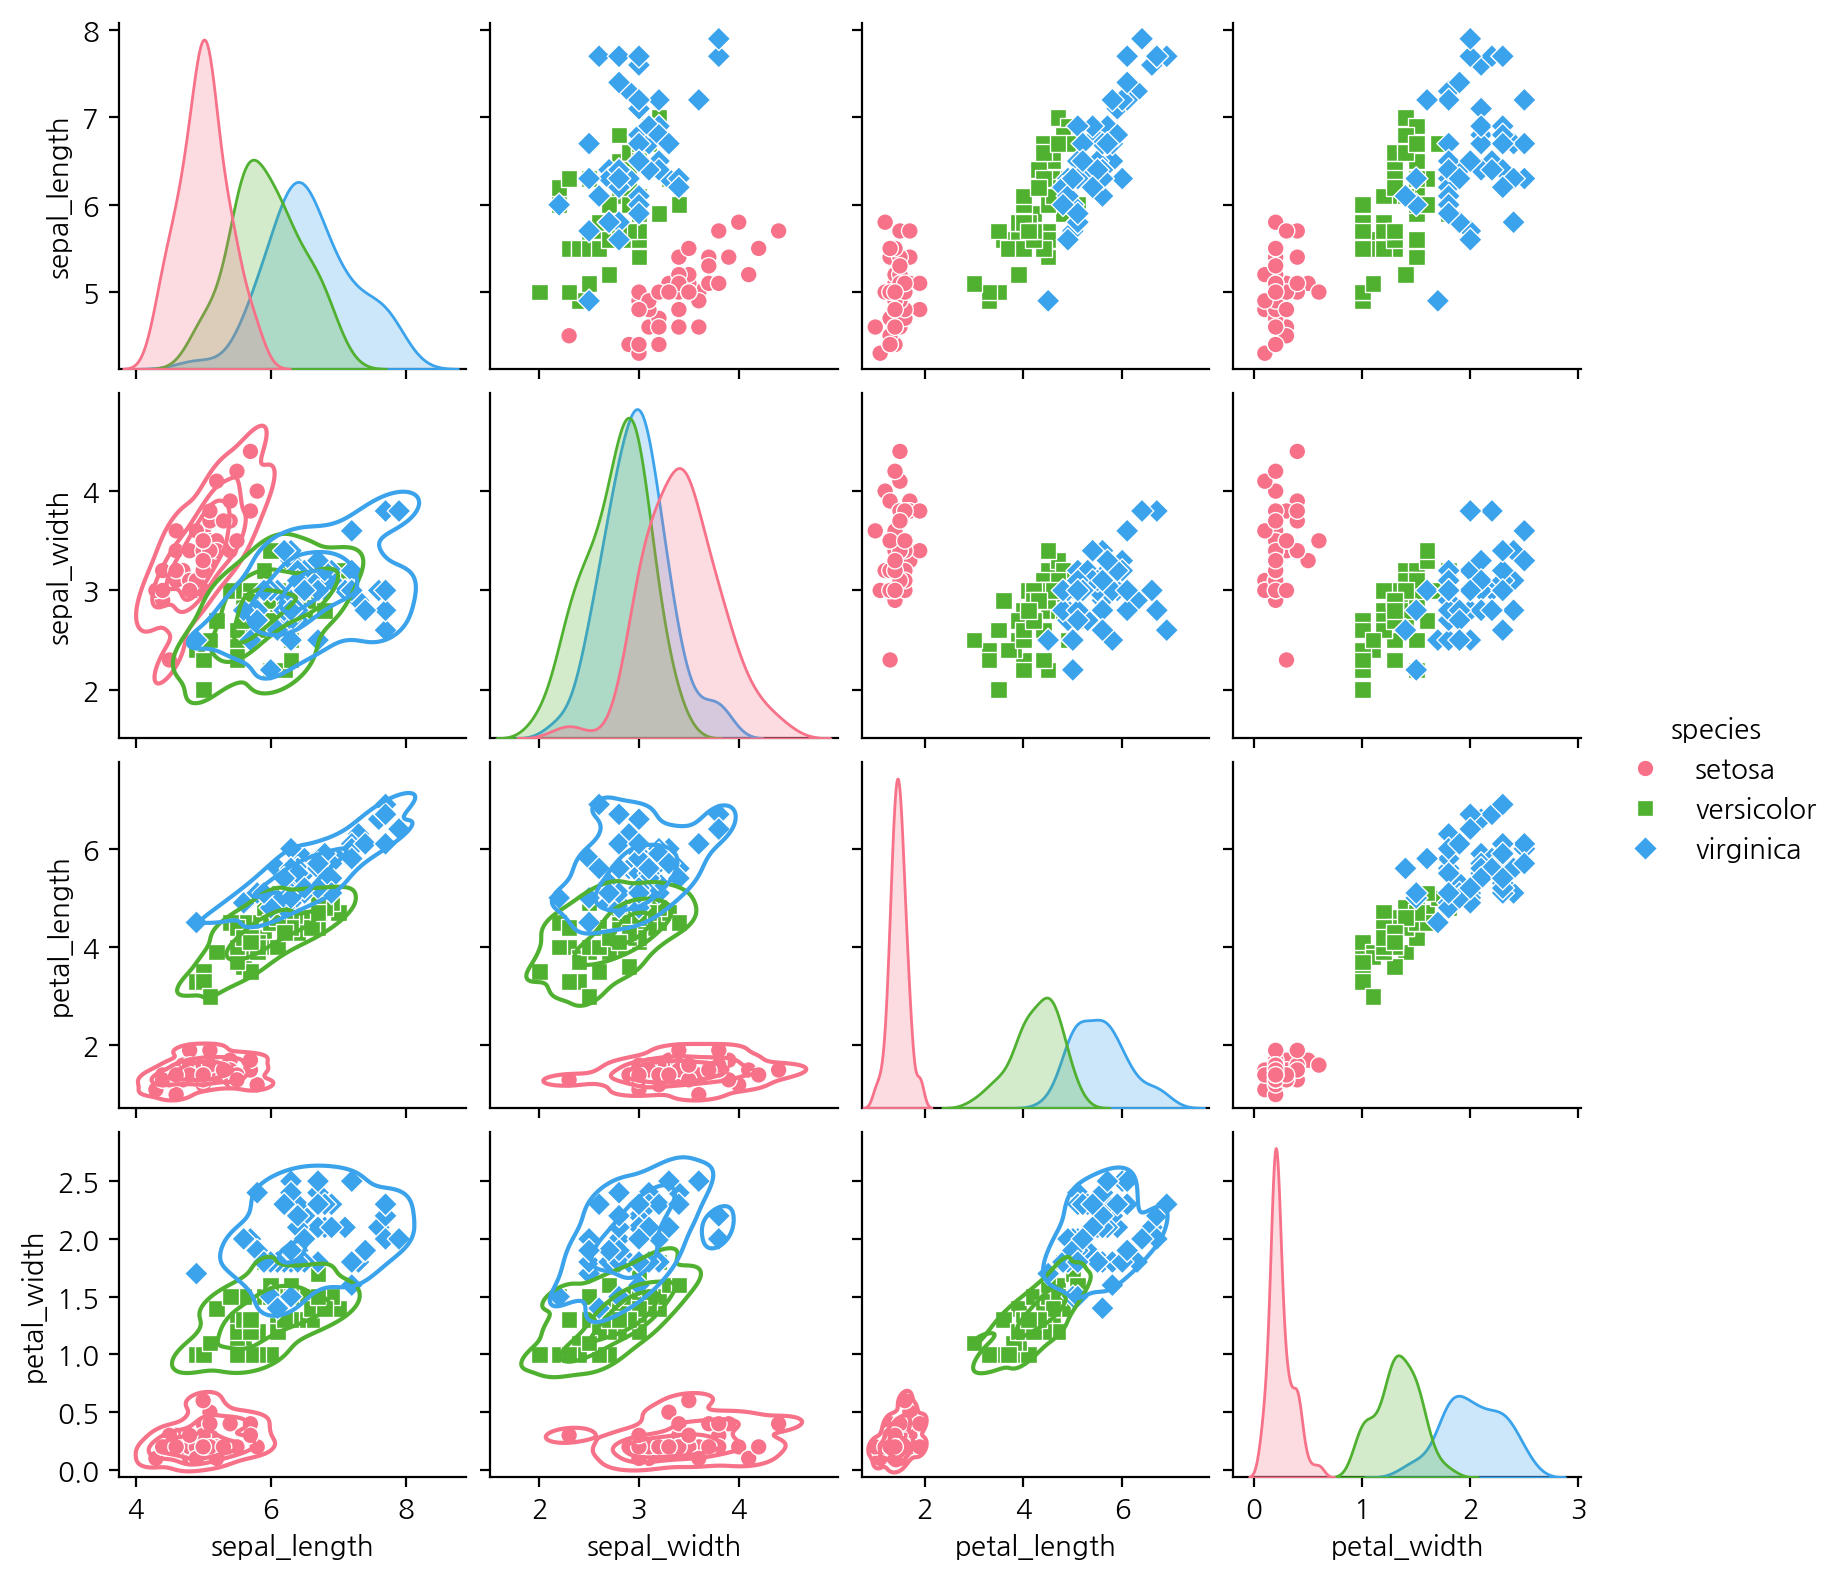

In [116]:
# PairGrid 반환 객체 활용
g = sns.pairplot(iris_sns, hue="species",
                 palette="husl",
                 height=2.0,
                 markers=["o", "s", "D"])

g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show()

## Appendix. airquality 데이터셋 결측값 분석 및 시각화

In [117]:
# airquality 데이터 불러오기
df = data('airquality')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 8.4 KB


In [118]:
# 앞부분 확인
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


In [119]:
# 기초 통계 확인
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [120]:
# 결측값 개수 확인
df.isnull().sum()

,0
Ozone,37
Solar.R,7
Wind,0
Temp,0
Month,0
Day,0


In [121]:
# 결측값이 있는 행 출력
df[df.isnull().any(axis=1)]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
10,NaN,194.0,8.6,69,5,10
11,7.0,NaN,6.9,74,5,11
25,NaN,66.0,16.6,57,5,25
26,NaN,266.0,14.9,58,5,26
27,NaN,NaN,8.0,57,5,27
32,NaN,286.0,8.6,78,6,1
33,NaN,287.0,9.7,74,6,2
34,NaN,242.0,16.1,67,6,3


In [122]:
# Ozone 결측값 행
df[df['Ozone'].isnull()]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
10,NaN,194.0,8.6,69,5,10
25,NaN,66.0,16.6,57,5,25
26,NaN,266.0,14.9,58,5,26
27,NaN,NaN,8.0,57,5,27
32,NaN,286.0,8.6,78,6,1
33,NaN,287.0,9.7,74,6,2
34,NaN,242.0,16.1,67,6,3
35,NaN,186.0,9.2,84,6,4
36,NaN,220.0,8.6,85,6,5


In [123]:
# Solar.R 결측값 행
df[df['Solar.R'].isnull()]

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
11,7.0,NaN,6.9,74,5,11
27,NaN,NaN,8.0,57,5,27
96,78.0,NaN,6.9,86,8,4
97,35.0,NaN,7.4,85,8,5
98,66.0,NaN,4.6,87,8,6


In [124]:
# 월별 Ozone 평균
df.groupby('Month')['Ozone'].mean()

,Ozone
Month,
5,23.615385
6,29.444444
7,59.115385
8,59.961538
9,31.448276


In [125]:
# 월별 Ozone 평균을 원본 행 수에 맞게 변환
df.groupby('Month')['Ozone'].transform('mean')

,Ozone
1,23.615385
2,23.615385
3,23.615385
4,23.615385
5,23.615385
6,23.615385
7,23.615385
8,23.615385
9,23.615385
10,23.615385


In [126]:
# 결측값 처리 전 확인
print("--- 결측값 처리 전 ---")
print(df.isnull().sum())

--- 결측값 처리 전 ---
Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64


In [127]:
# Ozone: 월별 평균값으로 대체
ozone_monthly_mean = df.groupby('Month')['Ozone'].transform('mean')
df['Ozone'] = df['Ozone'].fillna(ozone_monthly_mean)

# Solar.R: 전체 평균값으로 대체
df['Solar.R'] = df['Solar.R'].fillna(df['Solar.R'].mean())

print("\n--- 결측값 처리 후 ---")
print(df.isnull().sum())


--- 결측값 처리 후 ---
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


In [128]:
# 처리 후 기초 통계 확인
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,40.851262,185.931507,9.957516,77.882353,6.993464,15.803922
std,29.595147,87.960267,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,21.000000,120.000000,7.400000,72.000000,6.000000,8.000000
50%,29.444444,194.000000,9.700000,79.000000,7.000000,16.000000
75%,59.115385,256.000000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


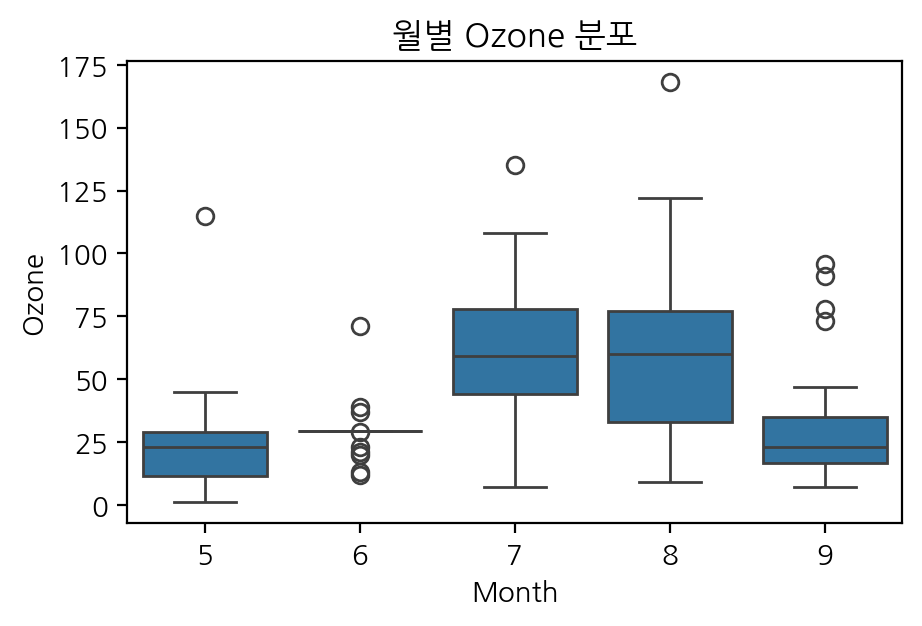

In [129]:
# Ozone 월별 상자그림
sns.boxplot(data=df, x='Month', y='Ozone')
plt.title('월별 Ozone 분포')
plt.show()

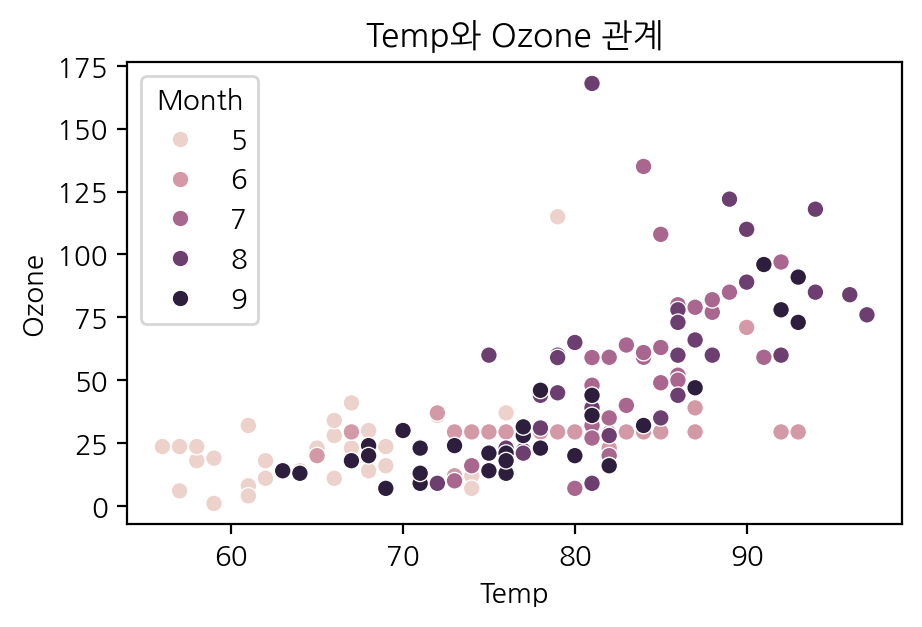

In [130]:
# Temp와 Ozone 산점도
sns.scatterplot(data=df, x='Temp', y='Ozone', hue='Month')
plt.title('Temp와 Ozone 관계')
plt.show()

In [131]:
# airquality 상관관계
corr_air = df.corr()
corr_air

,Ozone,Solar.R,Wind,Temp,Month,Day
Ozone,1.000000,0.293944,-0.516750,0.645638,0.225836,-0.020826
Solar.R,0.293944,1.000000,-0.055245,0.262569,-0.072904,-0.145621
Wind,-0.516750,-0.055245,1.000000,-0.457988,-0.178293,0.027181
Temp,0.645638,0.262569,-0.457988,1.000000,0.420947,-0.130593
Month,0.225836,-0.072904,-0.178293,0.420947,1.000000,-0.007962
Day,-0.020826,-0.145621,0.027181,-0.130593,-0.007962,1.000000


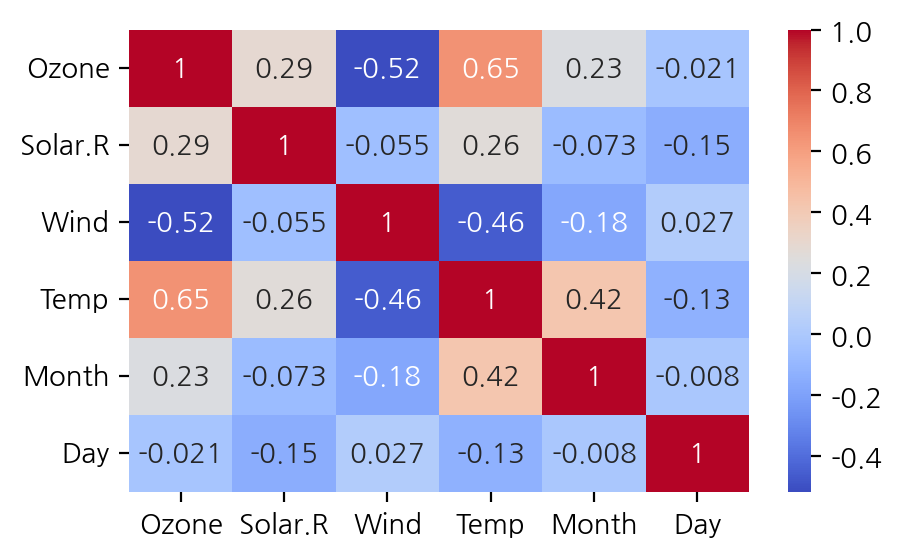

In [132]:
# airquality 상관관계 히트맵
sns.heatmap(corr_air, annot=True, cmap='coolwarm')
plt.show()